<a href="https://colab.research.google.com/github/LaureanoRomero/First_Repository/blob/master/ITAU6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### 1.0 Librerias

In [ ]:
!pip install pandasql
!pip install skopt
!pip install scikit-optimize
!pip install scikit-learn
!pip install azure-storage-blob
!pip install bayesian-optimization

ERROR: Could not find a version that satisfies the requirement skopt (from versions: none)
ERROR: No matching distribution found for skopt
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.9/404.9 kB 9.4 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.3/194.3 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.7/41.7 kB 2.9 MB/s eta 0:00:00


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import os
import pickle
import re
from skopt import BayesSearchCV
from pandasql import sqldf
from IPython.display import Image as PImage
from subprocess import check_call
from PIL import Image, ImageDraw, ImageFont
from sklearn.impute import KNNImputer
from scipy.stats import chi2_contingency
from sklearn.tree import DecisionTreeClassifier, export_graphviz, plot_tree
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression, LassoCV
from sklearn.metrics import   make_scorer, accuracy_score, confusion_matrix, classification_report, f1_score, roc_curve, auc, precision_recall_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sqlalchemy import create_engine
from sklearn.svm import SVC
from azure.storage.blob import BlobServiceClient
from io import BytesIO

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer
from skopt.utils import use_named_args
from skopt import gp_minimize
from skopt.plots import plot_objective, plot_histogram, plot_evaluations
from sklearn.metrics import average_precision_score

import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder


#### 2.0 Importación tabla .parquet

In [ ]:
# Cargar el archivo .parquet
desarrollo = pd.read_parquet('/kaggle/input/desarrollo')

# Mostrar las primeras filas del dataframe
desarrollo.head(200000)

,fallo,tecnologiapp,modelopp,tecnologiaaf,modeloaf,browser,grupo_version,mcc,grupo_version_ant,ciudadfin,...,prom_mes_dos,prom_mes_uno,total_terminales,cantidad_falla_m3,cantidad_falla_m2,cantidad_falla_mes1,antiguedad_creacion_terminal,antiguedad_version,antiguedad_compra_pos,antiguedad_puesta_pos
id,,,,,,,,,,,,,,,,,,,,,
Cy1AyK,0,a,i,b,h,g,g,aa,e,BOGOTÁ,...,2.200000,2.266667,3,0,0,3,1770,707,2502,278
UfC1Td,0,a,j,b,h,g,g,as,e,CÚCUTA,...,2.233333,1.000000,3,0,0,0,769,530,1542,273
ECDP8i,0,a,c,b,b,j,h,aaaag,k,MEDELLÍN,...,6.033333,4.400000,3,0,0,0,188,187,1911,187
vI3rKZ,0,a,c,b,b,g,g,ap,e,CALI,...,0.233333,0.333333,3,0,0,0,304,301,375,273
3hG7Yd,0,b,l,c,j,i,g,ad,e,POPAYÁN,...,1.466667,1.000000,12,0,0,0,2229,551,655,278
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DepVv9,0,b,m,c,k,i,g,aax,e,GUACHENÉ,...,19.700000,20.800000,6,0,0,0,3388,640,2624,12
Wdaipi,0,b,d,c,c,j,h,q,k,BOGOTÁ,...,9.500000,11.000000,3,0,0,0,691,160,1546,107
MIyuIO,0,a,j,b,i,h,g,aaaaaj,e,BOGOTÁ,...,6.700000,5.625000,3,0,0,3,1074,912,2139,271


#### 2.1 Validación tabla

In [ ]:
desarrollo.info()

<class 'pandas.core.frame.DataFrame'>
Index: 139998 entries, Cy1AyK to prRsFJ
Data columns (total 31 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   fallo                         139998 non-null  int64  
 1   tecnologiapp                  139998 non-null  object 
 2   modelopp                      139998 non-null  object 
 3   tecnologiaaf                  139998 non-null  object 
 4   modeloaf                      139998 non-null  object 
 5   browser                       139998 non-null  object 
 6   grupo_version                 139998 non-null  object 
 7   mcc                           139998 non-null  object 
 8   grupo_version_ant             139998 non-null  object 
 9   ciudadfin                     139998 non-null  object 
 10  trx_dia_cero                  139998 non-null  int64  
 11  trx_dia_uno                   139998 non-null  int64  
 12  trx_dia_dos                   139998 non-nul

#### 3.0 Análisis exploratorio de los datos (EDA)

In [ ]:
##################### ESTADISTICAS DESCRIPTIVAS  #####################
estadisticas_descriptivas = desarrollo.describe()

# Esto imprimirá las estadísticas descriptivas
print(estadisticas_descriptivas)

               fallo   trx_dia_cero    trx_dia_uno    trx_dia_dos  \
count  139998.000000  139998.000000  139998.000000  139998.000000   
mean        0.039336      15.652038      15.272254      19.003536   
std         0.194394      39.754678      38.711016      46.854166   
min         0.000000       0.000000       0.000000       0.000000   
25%         0.000000       0.000000       0.000000       0.000000   
50%         0.000000       3.000000       3.000000       6.000000   
75%         0.000000      15.000000      15.000000      18.000000   
max         1.000000    1359.000000    1521.000000    2031.000000   

        trx_dia_tres  trx_dia_cuatro  trx_dia_cinco   trx_dia_seis  \
count  139998.000000   139998.000000  139998.000000  139998.000000   
mean       17.922342       20.165581      17.642309      16.058415   
std        44.376617       47.523053      44.475883      41.718960   
min         0.000000        0.000000       0.000000       0.000000   
25%         0.000000        

In [ ]:
#calculate descriptive statistics for categorical variables only
desarrollo.astype('object').describe()

,fallo,tecnologiapp,modelopp,tecnologiaaf,modeloaf,browser,grupo_version,mcc,grupo_version_ant,ciudadfin,...,prom_mes_dos,prom_mes_uno,total_terminales,cantidad_falla_m3,cantidad_falla_m2,cantidad_falla_mes1,antiguedad_creacion_terminal,antiguedad_version,antiguedad_compra_pos,antiguedad_puesta_pos
count,139998,139998,139998,139998,139998,139998,139998,139998,139998,139998,...,139998.000000,139998.0,139998,139998,139998,139998,139998,139998,139998,139998
unique,2,4,18,5,13,14,11,143,11,728,...,2405.000000,2175.0,73,35,41,35,7018,1513,388,673
top,0,a,j,b,i,j,h,aaaaaj,e,BOGOTÁ,...,0.266667,0.2,3,0,0,0,321,43382,1014,0
freq,134491,105824,82378,82644,61147,76324,74575,15358,54808,42530,...,2033.000000,5462.0,85108,103122,106857,110846,181,2801,4601,20180


Cálculo la matriz de correlación de Pearson

In [ ]:
# Calcula la matriz de correlación de Pearson
# Seleccionar solo las variables numéricas
numericas = desarrollo.select_dtypes(include=['int64', 'float64']).drop(columns=['fallo'])

# Calcula la matriz de correlación
correlation_matrix = numericas.corr()

# Visualiza la matriz de correlación en forma de mapa de calor
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 10}, linewidths=.5)
plt.title('Matriz de Correlación')
plt.show()

In [ ]:
print(correlation_matrix)

                              trx_dia_cero  trx_dia_uno  trx_dia_dos  \
trx_dia_cero                      1.000000     0.850919     0.788556   
trx_dia_uno                       0.850919     1.000000     0.804121   
trx_dia_dos                       0.788556     0.804121     1.000000   
trx_dia_tres                      0.583891     0.584283     0.670687   
trx_dia_cuatro                    0.673432     0.660169     0.692636   
trx_dia_cinco                     0.742419     0.728577     0.793685   
trx_dia_seis                      0.731638     0.724667     0.787556   
trx_mes_tres                      0.771243     0.756881     0.819568   
trx_mes_dos                       0.796016     0.784898     0.843692   
trx_mes_uno                       0.794645     0.789848     0.890975   
prom_mes_tres                     0.771243     0.756881     0.819568   
prom_mes_dos                      0.796016     0.784898     0.843692   
prom_mes_uno                      0.840539     0.834312     0.89

#### 3.1 Analisis de correlación con var dependiente

Nota:
A partir de un analisis de correlación de pearson se encontro que algunas variables se encuentran altamente correlacionadas entre si una posible solución es crear unas nuevas variables que permita resumir la variabilidad, para los cual se van crear tres nuevas.
1. La mediana de todas las variables que empiecen por trx_dia_ y se va a llamar trx_dia_mediana
2. La mediana  de todas las variables que empiecen por trx_mes_ y se va a llamar trx_mes_mediana
3. La mediana  de todas las variables que empiecen por prom_mes_ y se va a llamar prom_mes_mediana
por ultimo elimina las variables con las cuales se realizaron los calculos de las 3 nuevas variables

In [ ]:
# 1. Identificar las columnas que comienzan con 'trx_dia_', 'trx_mes_' y 'prom_mes_'
trx_dia_cols = [col for col in desarrollo.columns if col.startswith('trx_dia_')]
trx_mes_cols = [col for col in desarrollo.columns if col.startswith('trx_mes_')]
prom_mes_cols = [col for col in desarrollo.columns if col.startswith('prom_mes_')]

# 2. Calcular las medianas y crear las nuevas columnas
desarrollo['trx_dia_mediana'] = desarrollo[trx_dia_cols].median(axis=1)
desarrollo['trx_mes_mediana'] = desarrollo[trx_mes_cols].median(axis=1)
desarrollo['prom_mes_mediana'] = desarrollo[prom_mes_cols].median(axis=1)

# 3. Eliminar las columnas originales utilizadas para calcular las medianas
desarrollo.drop(columns=trx_dia_cols + trx_mes_cols + prom_mes_cols, inplace=True)


In [ ]:
# Calcula la matriz de correlación de Pearson
# Seleccionar solo las variables numéricas
numericas = desarrollo.select_dtypes(include=['int64', 'float64'])

# Calcula la matriz de correlación
correlation_matrix = numericas.corr()

# Visualiza la matriz de correlación en forma de mapa de calor
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 10}, linewidths=.5)
plt.title('Matriz de Correlación')
plt.show()

Nota:

Elimino los problemas de multicolinenalidad que todavía persisten

In [ ]:
desarrollo.drop(columns=["prom_mes_mediana", "trx_dia_mediana"], inplace=True)

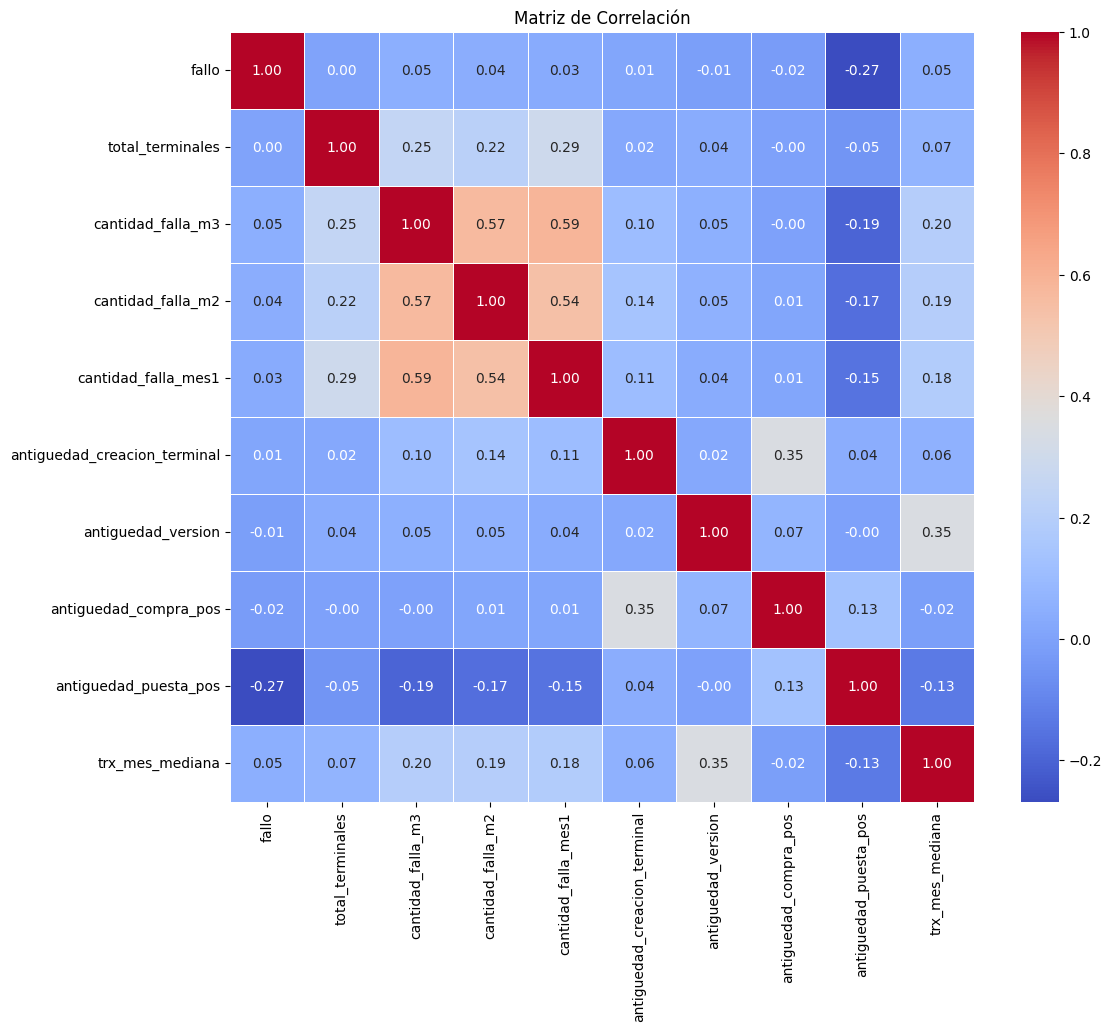

In [ ]:
# Calcula la matriz de correlación de Pearson
# Seleccionar solo las variables numéricas
numericas = desarrollo.select_dtypes(include=['int64', 'float64'])

# Calcula la matriz de correlación
correlation_matrix = numericas.corr()

# Visualiza la matriz de correlación en forma de mapa de calor
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 10}, linewidths=.5)
plt.title('Matriz de Correlación')
plt.show()

#### 3.2 Comportamiento de la variable respuesta y las variables explicativas

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


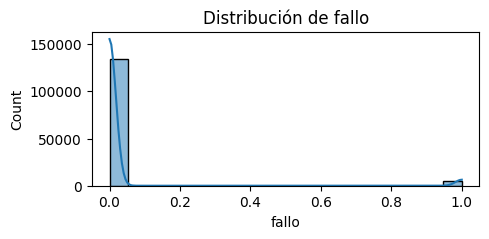

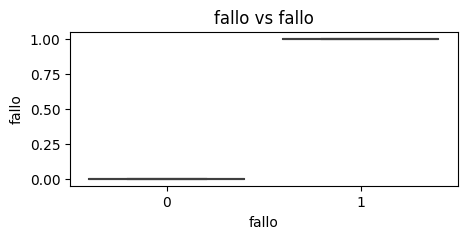

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


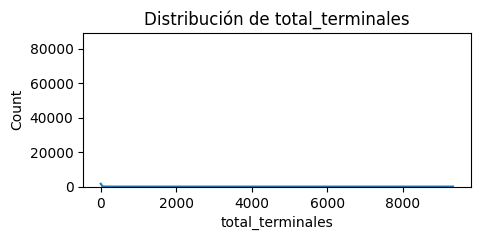

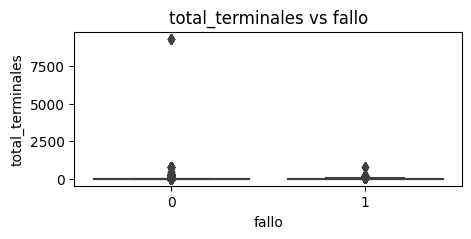

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


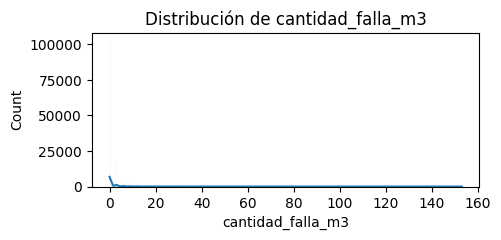

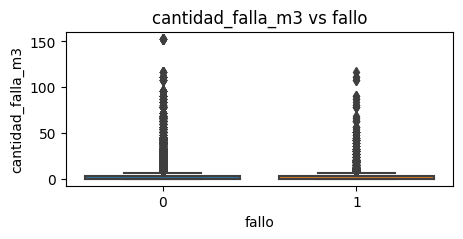

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


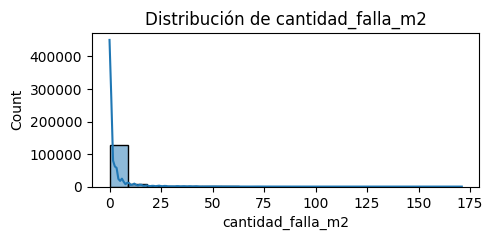

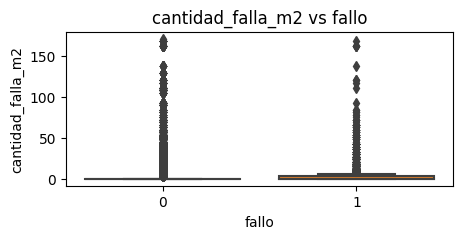

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


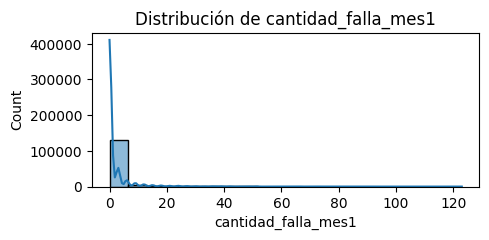

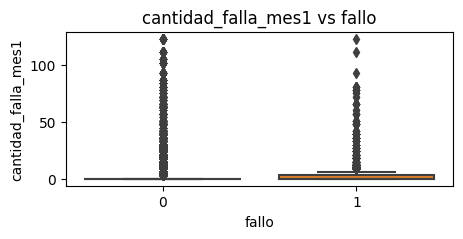

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


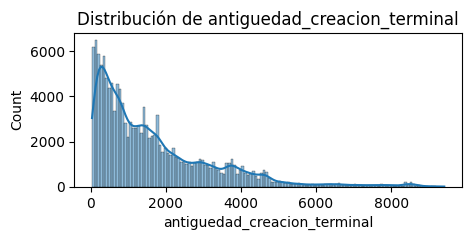

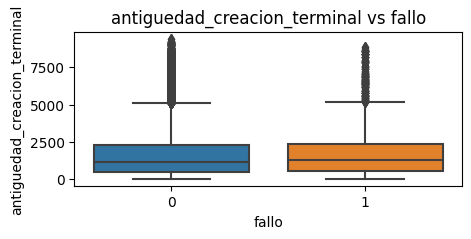

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


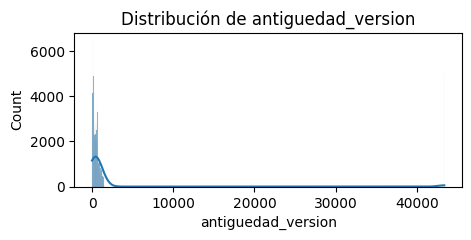

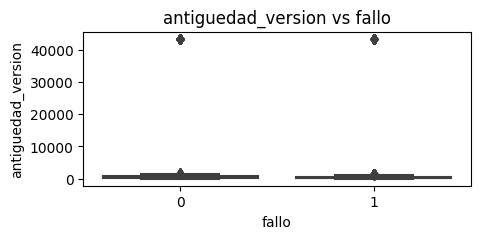

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


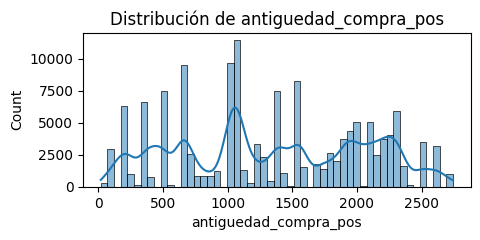

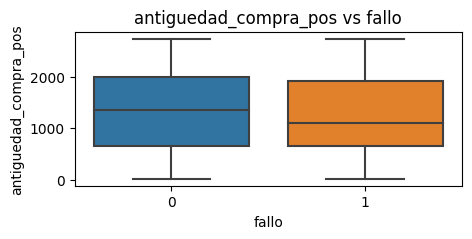

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


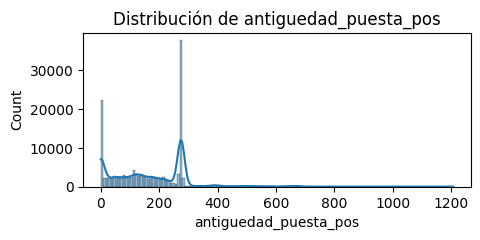

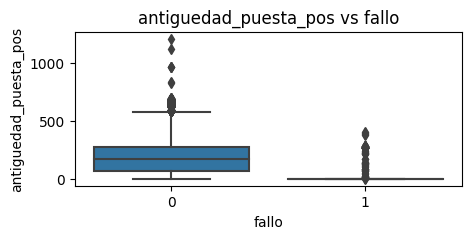

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


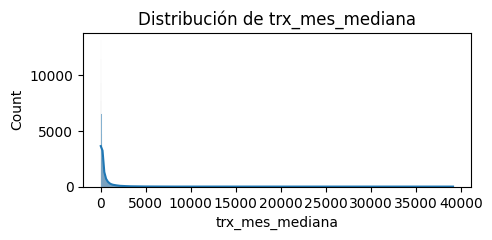

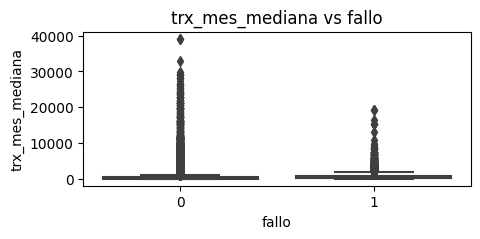

In [ ]:

# Seleccionar solo las variables numéricas
numeric_vars = desarrollo.select_dtypes(include=['float64', 'int64']).columns

for var in numeric_vars:
    plt.figure(figsize=(5, 2))
    sns.histplot(desarrollo[var], kde=True)
    plt.title(f'Distribución de {var}')
    plt.show()

    plt.figure(figsize=(5, 2))
    sns.boxplot(x=desarrollo['fallo'], y=desarrollo[var])
    plt.title(f'{var} vs fallo')
    plt.show()


#### 3.3 Verificacion de valores vacios

In [ ]:
# Calcular el porcentaje de valores nulos por columna
nan_percentage = desarrollo.isna().mean() * 100
print("\nPorcentaje de valores nulos por columna:")
print(nan_percentage)


Porcentaje de valores nulos por columna:
fallo                           0.0
tecnologiapp                    0.0
modelopp                        0.0
tecnologiaaf                    0.0
modeloaf                        0.0
browser                         0.0
grupo_version                   0.0
mcc                             0.0
grupo_version_ant               0.0
ciudadfin                       0.0
total_terminales                0.0
cantidad_falla_m3               0.0
cantidad_falla_m2               0.0
cantidad_falla_mes1             0.0
antiguedad_creacion_terminal    0.0
antiguedad_version              0.0
antiguedad_compra_pos           0.0
antiguedad_puesta_pos           0.0
trx_mes_mediana                 0.0
dtype: float64


Nota:

Paso la variable respuesta de numerica a object

In [ ]:
# Convertir la variable 'respuesta' a tipo 'object' y renombrarla a 'fallo'
desarrollo['fallo'] = desarrollo['fallo'].astype('object')

# Eliminar la columna original 'fallo' (si existe)
#desarrollo = desarrollo.drop('fallo', axis=1)


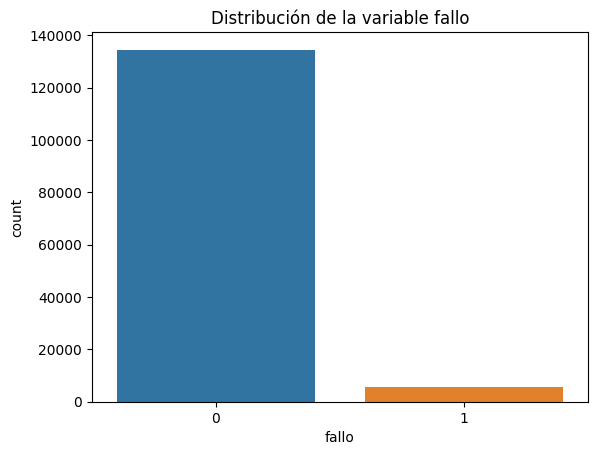

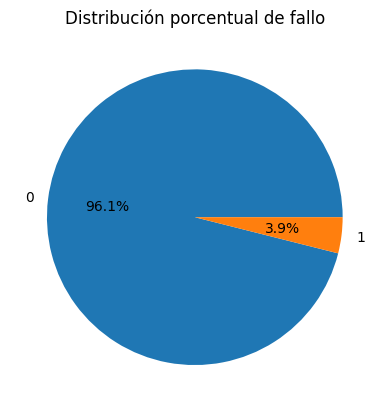

In [ ]:
# Suponiendo que tienes un DataFrame llamado 'df' y la columna 'fallo' es categórica

# Gráfico de barras simple
sns.countplot(x='fallo', data=desarrollo)
plt.title('Distribución de la variable fallo')
plt.show()

# Gráfico de pastel
plt.pie(desarrollo['fallo'].value_counts(), labels=desarrollo['fallo'].unique(), autopct='%1.1f%%')
plt.title('Distribución porcentual de fallo')
plt.show()

Nota:

Se esta trabajando con un conjunto de datos desequilibrado

In [ ]:
desarrollo.info()

<class 'pandas.core.frame.DataFrame'>
Index: 139998 entries, Cy1AyK to prRsFJ
Data columns (total 19 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   fallo                         139998 non-null  object 
 1   tecnologiapp                  139998 non-null  object 
 2   modelopp                      139998 non-null  object 
 3   tecnologiaaf                  139998 non-null  object 
 4   modeloaf                      139998 non-null  object 
 5   browser                       139998 non-null  object 
 6   grupo_version                 139998 non-null  object 
 7   mcc                           139998 non-null  object 
 8   grupo_version_ant             139998 non-null  object 
 9   ciudadfin                     139998 non-null  object 
 10  total_terminales              139998 non-null  int64  
 11  cantidad_falla_m3             139998 non-null  int64  
 12  cantidad_falla_m2             139998 non-nul

#### 3.5 Manejo de valores atípicos.

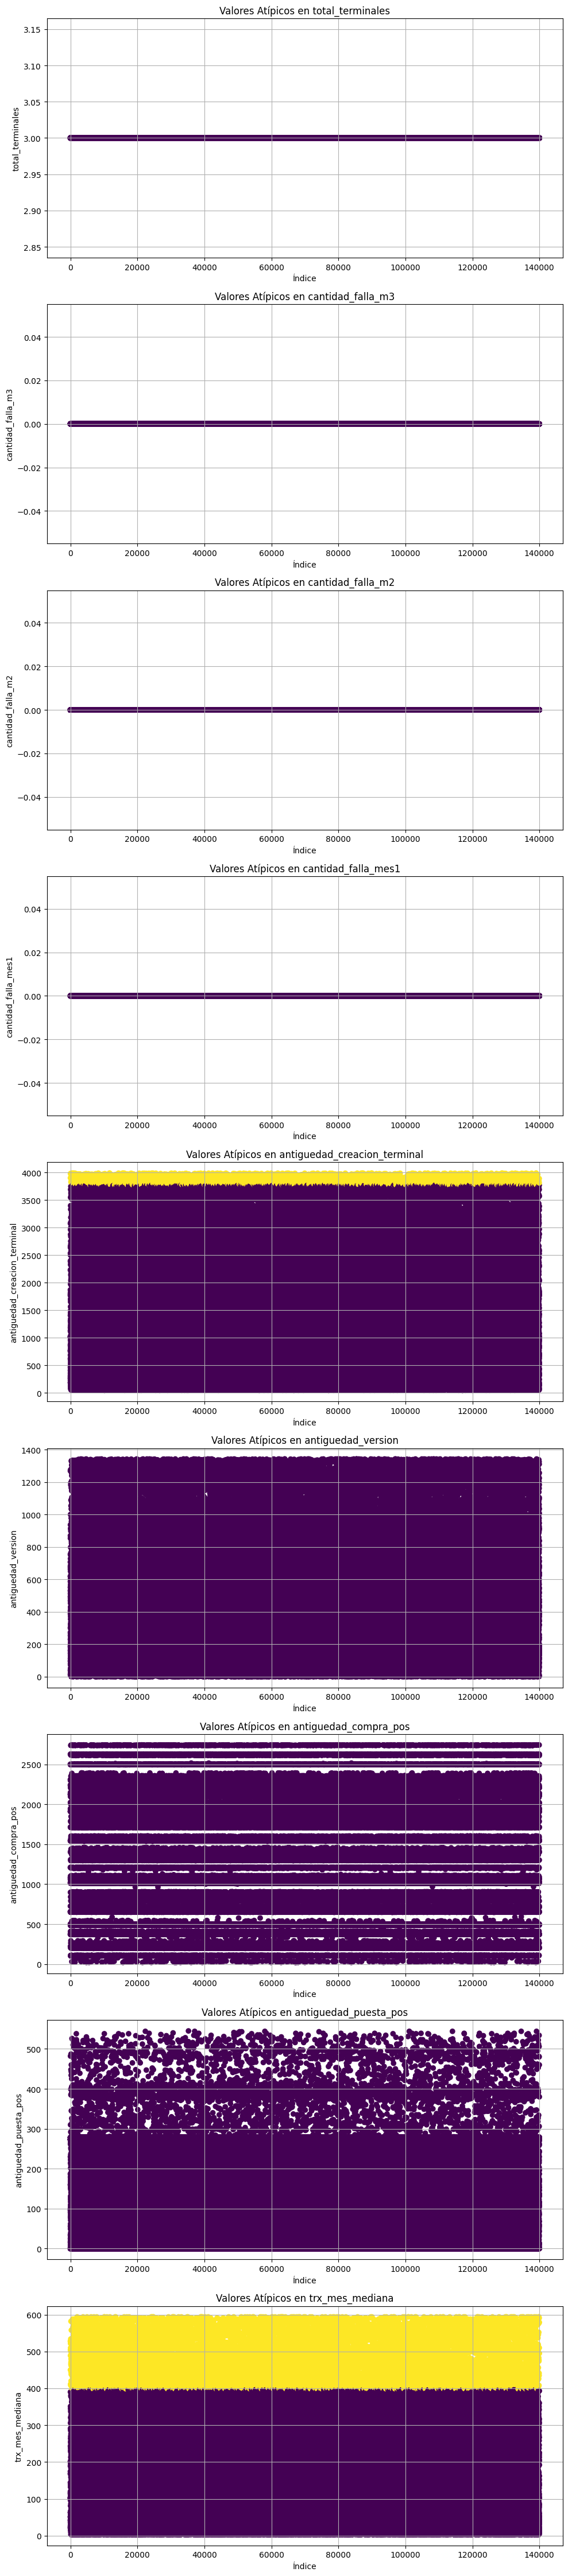

In [ ]:
# Función para detectar y reemplazar valores atípicos por la mediana de los no atípicos
def detectar_y_reemplazar_atipicos(dataset, threshold=3.5):
    # Filtrar solo las columnas numéricas
    columnas_numericas = dataset.select_dtypes(include=['float64', 'int64'])

    # Identificar los valores atípicos en cada columna numérica
    atipicos = pd.DataFrame(index=columnas_numericas.index, columns=columnas_numericas.columns)
    for columna in columnas_numericas.columns:
        mediana = columnas_numericas[columna].median()
        # Calcular MAD manualmente
        mad = np.median(np.abs(columnas_numericas[columna] - mediana))

        # Evitar división por cero
        if mad == 0:
            mad = 1e-6  # Un pequeño valor para evitar NaN si MAD es cero

        atipicos[columna] = np.abs(columnas_numericas[columna] - mediana) / mad > threshold

    # Reemplazar valores atípicos por la mediana de los valores no atípicos
    for columna in columnas_numericas.columns:
        no_atipicos = columnas_numericas[~atipicos[columna]][columna]
        mediana_no_atipicos = no_atipicos.median()

        # Reemplazar solo los valores atípicos en el dataset original
        dataset.loc[atipicos[columna], columna] = mediana_no_atipicos

    return dataset

# Función para graficar valores atípicos
def graficar_atipicos(dataset):
    # Filtrar solo las columnas numéricas
    columnas_numericas = dataset.select_dtypes(include=['float64', 'int64'])

    # Calcular el rango intercuartílico (IQR) para cada columna numérica
    Q1 = columnas_numericas.quantile(0.25)
    Q3 = columnas_numericas.quantile(0.75)
    IQR = Q3 - Q1

    # Definir los límites inferior y superior para detectar valores atípicos
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identificar los valores atípicos en cada columna numérica
    atipicos = (columnas_numericas < lower_bound) | (columnas_numericas > upper_bound)

    # Graficar los valores atípicos por columna
    fig, axes = plt.subplots(nrows=len(columnas_numericas.columns), ncols=1, figsize=(10, 5 * len(columnas_numericas.columns)))
    if len(columnas_numericas.columns) == 1:
        axes = [axes]  # Asegurar que axes sea iterable cuando solo hay una columna

    for i, columna in enumerate(columnas_numericas.columns):
        axes[i].scatter(range(len(columnas_numericas)), columnas_numericas[columna], c=atipicos[columna], cmap='viridis')
        axes[i].set_title('Valores Atípicos en {}'.format(columna))
        axes[i].set_xlabel('Índice')
        axes[i].set_ylabel(columna)
        axes[i].grid(True)

    plt.tight_layout()
    plt.show()

# Uso de las funciones con el dataset 'desarrollo'
desarrollo = detectar_y_reemplazar_atipicos(desarrollo)
graficar_atipicos(desarrollo)

Nota: Analisis de vacios sobre variables del dataframe

In [ ]:
desarrollo.isnull().sum()

fallo                           0
tecnologiapp                    0
modelopp                        0
tecnologiaaf                    0
modeloaf                        0
browser                         0
grupo_version                   0
mcc                             0
grupo_version_ant               0
ciudadfin                       0
total_terminales                0
cantidad_falla_m3               0
cantidad_falla_m2               0
cantidad_falla_mes1             0
antiguedad_creacion_terminal    0
antiguedad_version              0
antiguedad_compra_pos           0
antiguedad_puesta_pos           0
trx_mes_mediana                 0
dtype: int64

In [ ]:
desarrollo.head(4)

,fallo,tecnologiapp,modelopp,tecnologiaaf,modeloaf,browser,grupo_version,mcc,grupo_version_ant,ciudadfin,total_terminales,cantidad_falla_m3,cantidad_falla_m2,cantidad_falla_mes1,antiguedad_creacion_terminal,antiguedad_version,antiguedad_compra_pos,antiguedad_puesta_pos,trx_mes_mediana
id,,,,,,,,,,,,,,,,,,,
Cy1AyK,0,a,i,b,h,g,g,aa,e,BOGOTÁ,3,0,0,0,1770,707,2502,278,168.0
UfC1Td,0,a,j,b,h,g,g,as,e,CÚCUTA,3,0,0,0,769,530,1542,273,201.0
ECDP8i,0,a,c,b,b,j,h,aaaag,k,MEDELLÍN,3,0,0,0,188,187,1911,187,528.0
vI3rKZ,0,a,c,b,b,g,g,ap,e,CALI,3,0,0,0,304,301,375,273,21.0


#### 3.6 Estandarizacion de variables

In [ ]:
from sklearn.preprocessing import StandardScaler

# Seleccionar solo las variables numéricas para estandarizar, excluyendo la variable 'fallo'
numericas = desarrollo.select_dtypes(include=['int64', 'float64'])

# Inicializar el objeto StandardScaler
scaler = StandardScaler()

# Ajustar y transformar los datos numéricos
numericas_estandarizadas = scaler.fit_transform(numericas)

# Crear un nuevo DataFrame con las variables estandarizadas, conservando los índices originales
numericas_estandarizadas_df = pd.DataFrame(numericas_estandarizadas, columns=numericas.columns, index=desarrollo.index)

# Combinar las variables estandarizadas con las variables categóricas
train_t = pd.concat([numericas_estandarizadas_df, desarrollo.select_dtypes(include=['object'])], axis=1)

# Reconstruir el DataFrame final incluyendo la variable objetivo 'fallo'
#desarrollo = pd.concat([desarrollo[['fallo']], train_t], axis=1)

# Verificar si hay valores nulos
print(desarrollo.isnull().sum())


fallo                           0
tecnologiapp                    0
modelopp                        0
tecnologiaaf                    0
modeloaf                        0
browser                         0
grupo_version                   0
mcc                             0
grupo_version_ant               0
ciudadfin                       0
total_terminales                0
cantidad_falla_m3               0
cantidad_falla_m2               0
cantidad_falla_mes1             0
antiguedad_creacion_terminal    0
antiguedad_version              0
antiguedad_compra_pos           0
antiguedad_puesta_pos           0
trx_mes_mediana                 0
dtype: int64


#### 3.7 Analisis Exploratorio cualitativo


Analisis de frecuencia de categorías

In [ ]:
# Seleccionar las variables cualitativas
variables_cualitativas = desarrollo.select_dtypes(include=['object'])
cantidad_categorias = variables_cualitativas.nunique()
cantidad_categorias

fallo                  2
tecnologiapp           4
modelopp              18
tecnologiaaf           5
modeloaf              13
browser               14
grupo_version         11
mcc                  143
grupo_version_ant     11
ciudadfin            728
dtype: int64

In [ ]:
# Verificar si hay valores NaN en el DataFrame
nan_check = desarrollo.isna().any()
# Imprimir las columnas que contienen valores NaN, si las hay
print("Columnas con valores NaN:")
print(nan_check[nan_check])

Columnas con valores NaN:
Series([], dtype: bool)


In [ ]:
# Iterar sobre cada variable cualitativa y mostrar la frecuencia por categoría de la variable
for columna in variables_cualitativas.columns:
    print(f"Frecuencia de valores para la variable {columna}:")
    print(desarrollo[columna].value_counts())
    print()

Frecuencia de valores para la variable fallo:
fallo
0    134491
1      5507
Name: count, dtype: int64

Frecuencia de valores para la variable tecnologiapp:
tecnologiapp
a    105824
b     34071
d        83
c        20
Name: count, dtype: int64

Frecuencia de valores para la variable modelopp:
modelopp
j    82378
c    16447
l    12977
i     6016
n     5720
a     5600
d     5067
k     3068
r      950
m      872
q      273
o      264
f      149
p       83
e       73
g       33
b       20
h        8
Name: count, dtype: int64

Frecuencia de valores para la variable tecnologiaaf:
tecnologiaaf
b    82644
c    33590
a    18621
d     5007
e      136
Name: count, dtype: int64

Frecuencia de valores para la variable modeloaf:
modeloaf
i    61147
h    23812
b    16289
j    15904
k     6794
c     5014
g     5007
a     4570
m      948
l      273
e      147
d       76
f       17
Name: count, dtype: int64

Frecuencia de valores para la variable browser:
browser
j    76324
g    32024
h    17903
i     71

#### 3.8 Agrupación de categorias, para reducir dimensionalidad

Agrupación de categorías

In [ ]:
# Agrupación de categorías en la variable "tecnologiapp"
desarrollo['tecnologiapp'] = desarrollo['tecnologiapp'].replace({'c': 'cd', 'd': 'cd'})

# Agrupación de categorías en la variable "modelopp"
desarrollo['modelopp'] = desarrollo['modelopp'].replace({'q': 'qofpegbh', 'o': 'qofpegbh', 'f': 'qofpegbh', 'p': 'qofpegbh',
                                                         'e': 'qofpegbh', 'g': 'qofpegbh', 'b': 'qofpegbh', 'h': 'qofpegbh'})

# Agrupación de categorías en la variable "tecnologiaaf"
desarrollo['tecnologiaaf'] = desarrollo['tecnologiaaf'].replace({'d': 'de', 'e': 'de'})

# Agrupación de categorías en la variable "modeloaf"
desarrollo['modeloaf'] = desarrollo['modeloaf'].replace({'m': 'mledf', 'l': 'mledf', 'e': 'mledf', 'd': 'mledf', 'f': 'mledf'})

# Agrupación de categorías en la variable "browser"
desarrollo['browser'] = desarrollo['browser'].replace({'b': 'bkamld', 'k': 'bkamld', 'a': 'bkamld', 'm': 'bkamld',
                                                       'l': 'bkamld', 'd': 'bkamld'})

# Agrupación de categorías en la variable "grupo_version"
desarrollo['grupo_version'] = desarrollo['grupo_version'].replace({'a': 'aic', 'i': 'aic', 'c': 'aic'})

# Agrupación de categorías en la variable "grupo_version_ant"
desarrollo['grupo_version_ant'] = desarrollo['grupo_version_ant'].replace({'i': 'ija', 'j': 'ija', 'a': 'ija'})

# Agrupación de categorías únicas en "mcc"
categorias_grupo_mcc = desarrollo['mcc'].value_counts()
categorias_unicas_grupo_mcc = categorias_grupo_mcc[categorias_grupo_mcc == 1].index
desarrollo['mcc'] = desarrollo['mcc'].replace(categorias_unicas_grupo_mcc, 'otros_grupo_mcc')

# Agrupación de categorías únicas en "ciudadfin"
categorias_ciudadfin = desarrollo['ciudadfin'].value_counts()
categorias_unicas_ciudadfin = categorias_ciudadfin[categorias_ciudadfin == 1].index
desarrollo['ciudadfin'] = desarrollo['ciudadfin'].replace(categorias_unicas_ciudadfin, 'otros_ciudadfin')


Verificación

In [ ]:
# Iterar sobre cada variable cualitativa y mostrar la frecuencia por categoría de la variable
for columna in variables_cualitativas.columns:
    print(f"Frecuencia de valores para la variable {columna}:")
    print(desarrollo[columna].value_counts())
    print()

Frecuencia de valores para la variable fallo:
fallo
0    134491
1      5507
Name: count, dtype: int64

Frecuencia de valores para la variable tecnologiapp:
tecnologiapp
a     105824
b      34071
cd       103
Name: count, dtype: int64

Frecuencia de valores para la variable modelopp:
modelopp
j           82378
c           16447
l           12977
i            6016
n            5720
a            5600
d            5067
k            3068
r             950
qofpegbh      903
m             872
Name: count, dtype: int64

Frecuencia de valores para la variable tecnologiaaf:
tecnologiaaf
b     82644
c     33590
a     18621
de     5143
Name: count, dtype: int64

Frecuencia de valores para la variable modeloaf:
modeloaf
i        61147
h        23812
b        16289
j        15904
k         6794
c         5014
g         5007
a         4570
mledf     1461
Name: count, dtype: int64

Frecuencia de valores para la variable browser:
browser
j         76324
g         32024
h         17903
i          7196
n

In [ ]:
# Calcular el porcentaje de valores nulos por columna
nan_percentage = desarrollo.isna().mean() * 100
print("\nPorcentaje de valores nulos por columna:")
print(nan_percentage)


Porcentaje de valores nulos por columna:
fallo                           0.0
tecnologiapp                    0.0
modelopp                        0.0
tecnologiaaf                    0.0
modeloaf                        0.0
browser                         0.0
grupo_version                   0.0
mcc                             0.0
grupo_version_ant               0.0
ciudadfin                       0.0
total_terminales                0.0
cantidad_falla_m3               0.0
cantidad_falla_m2               0.0
cantidad_falla_mes1             0.0
antiguedad_creacion_terminal    0.0
antiguedad_version              0.0
antiguedad_compra_pos           0.0
antiguedad_puesta_pos           0.0
trx_mes_mediana                 0.0
dtype: float64


In [ ]:
desarrollo.info()

<class 'pandas.core.frame.DataFrame'>
Index: 139998 entries, Cy1AyK to prRsFJ
Data columns (total 19 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   fallo                         139998 non-null  object 
 1   tecnologiapp                  139998 non-null  object 
 2   modelopp                      139998 non-null  object 
 3   tecnologiaaf                  139998 non-null  object 
 4   modeloaf                      139998 non-null  object 
 5   browser                       139998 non-null  object 
 6   grupo_version                 139998 non-null  object 
 7   mcc                           139998 non-null  object 
 8   grupo_version_ant             139998 non-null  object 
 9   ciudadfin                     139998 non-null  object 
 10  total_terminales              139998 non-null  int64  
 11  cantidad_falla_m3             139998 non-null  int64  
 12  cantidad_falla_m2             139998 non-nul

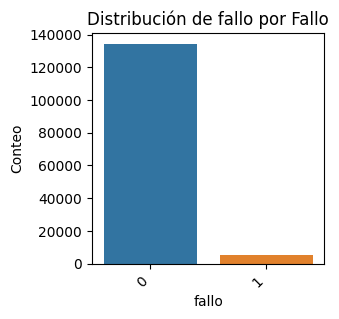

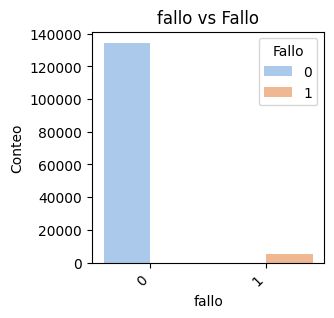

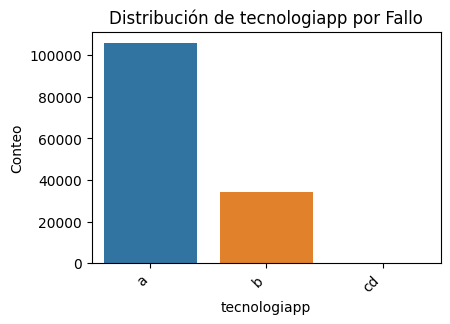

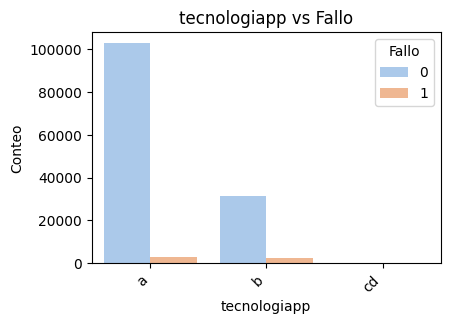

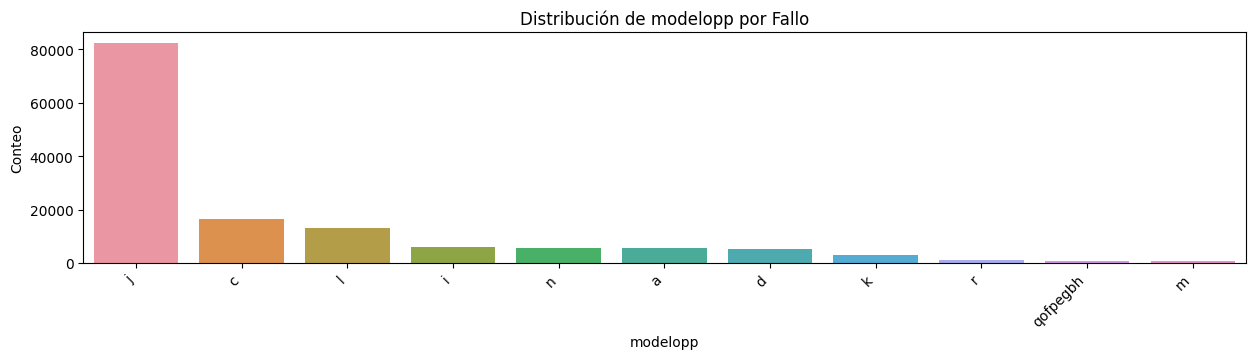

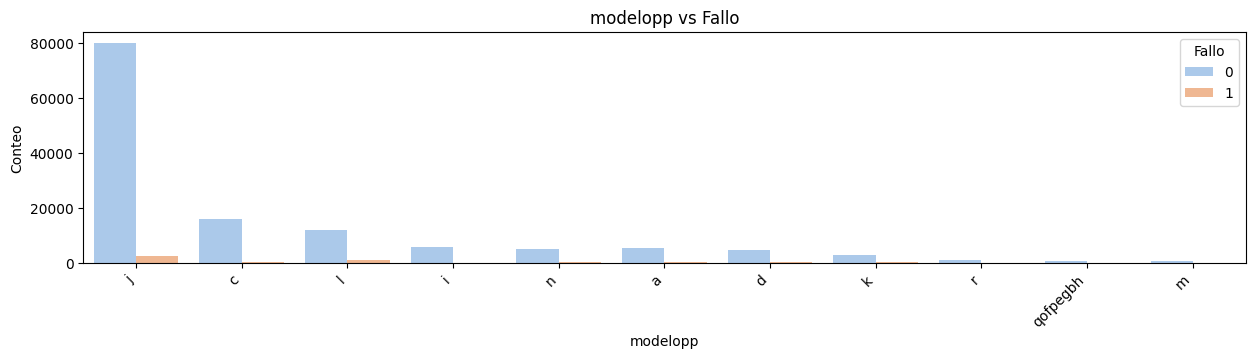

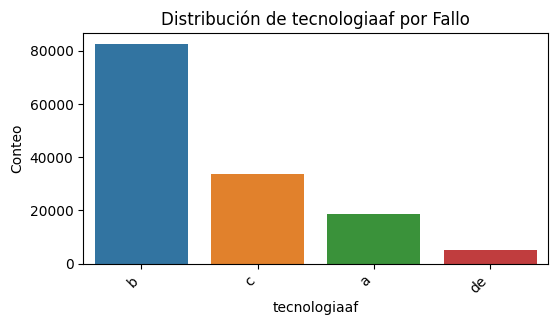

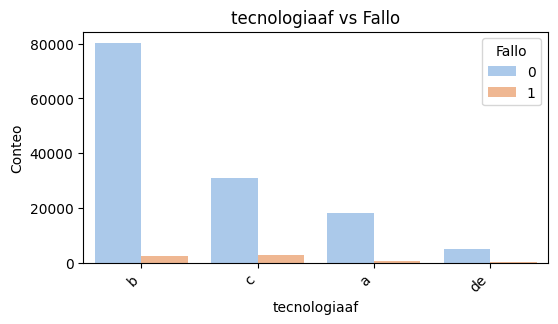

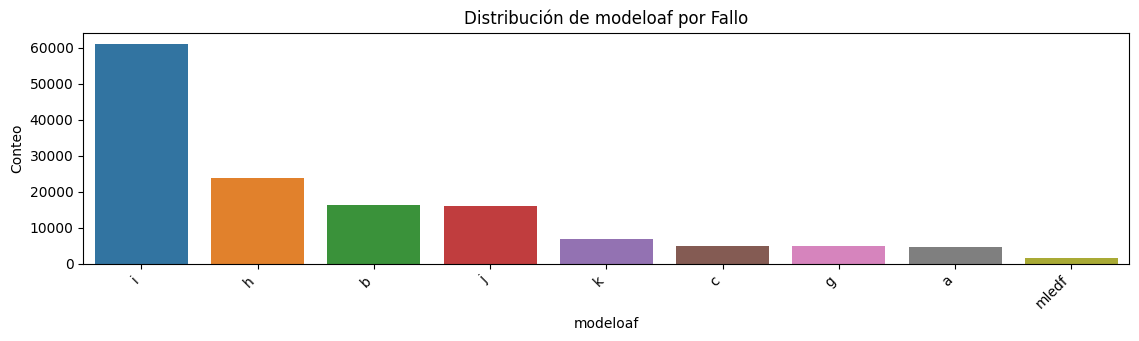

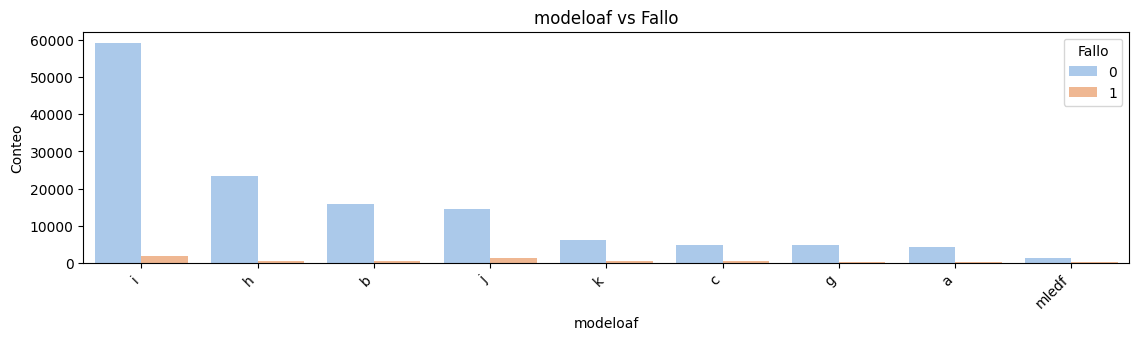

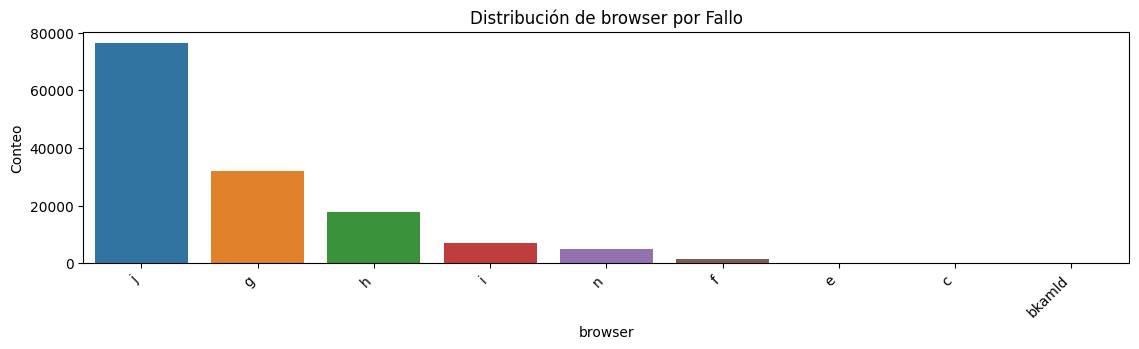

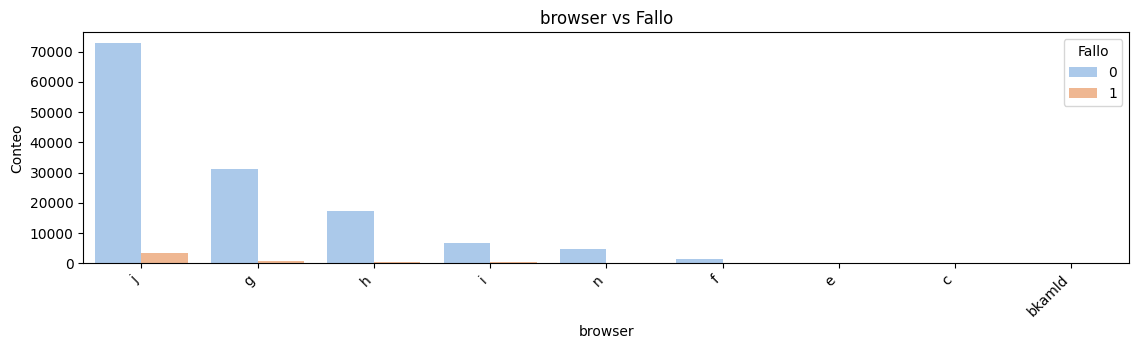

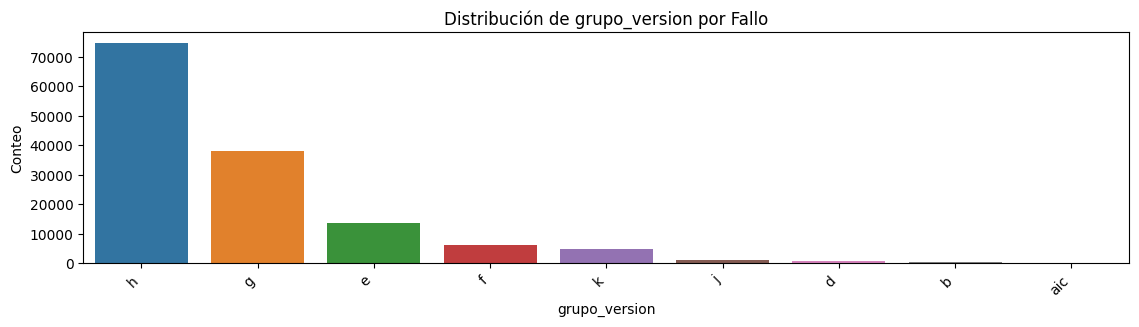

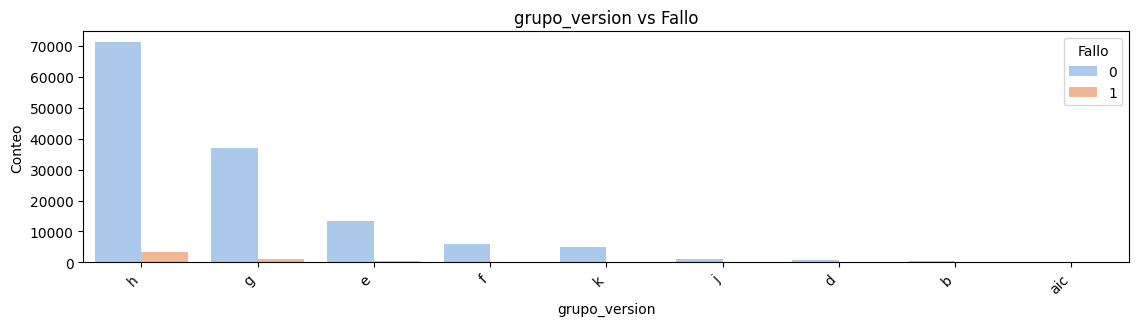

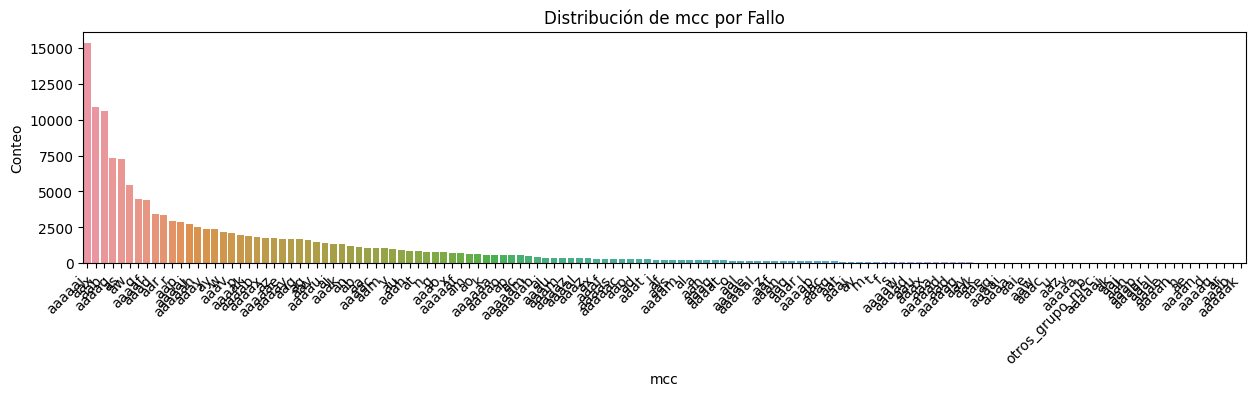

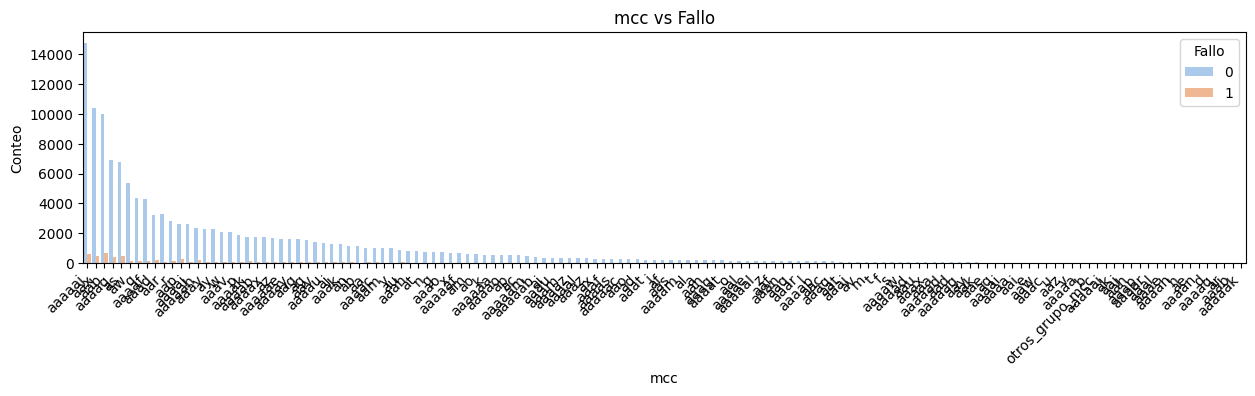

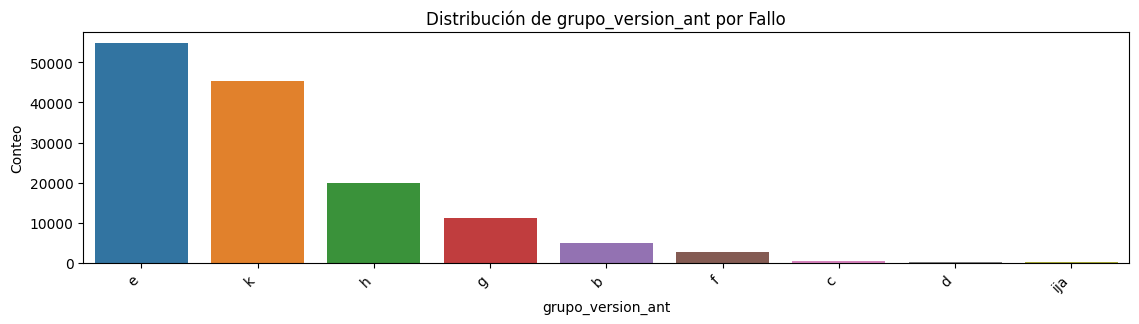

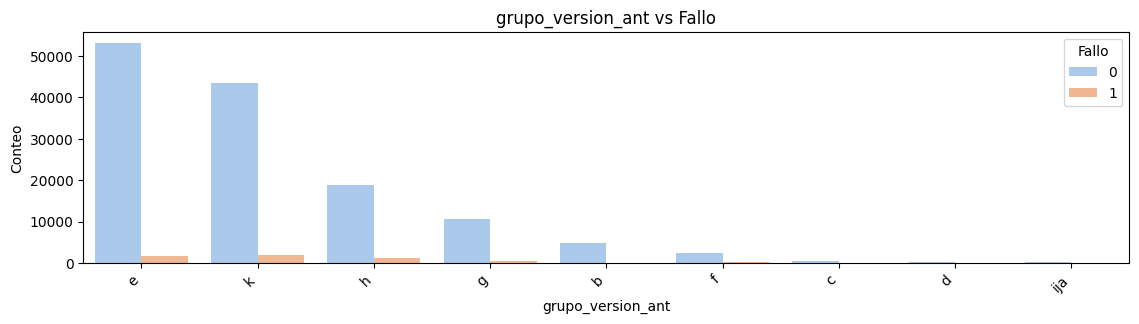

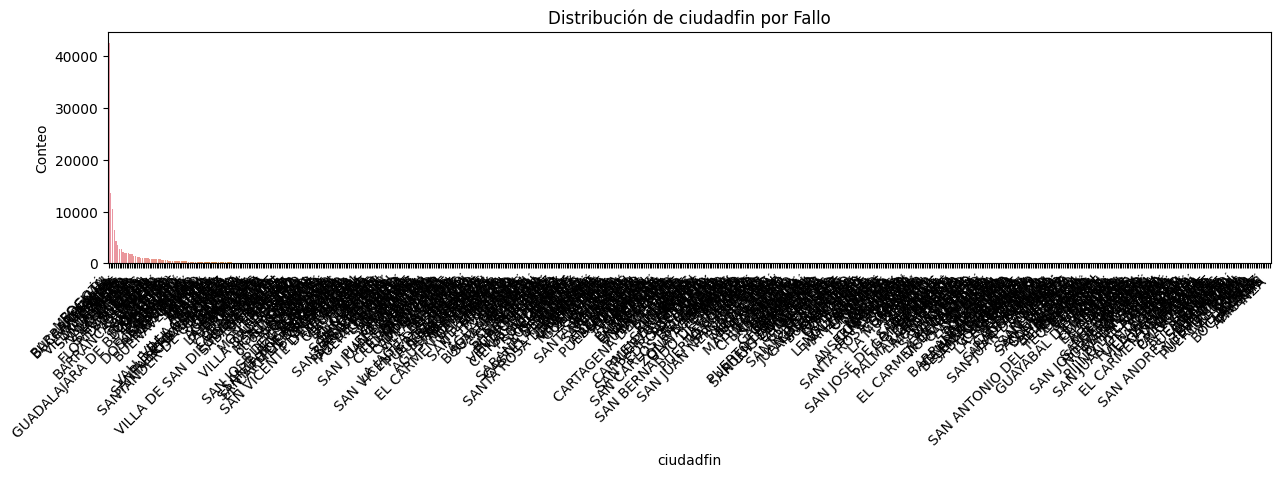

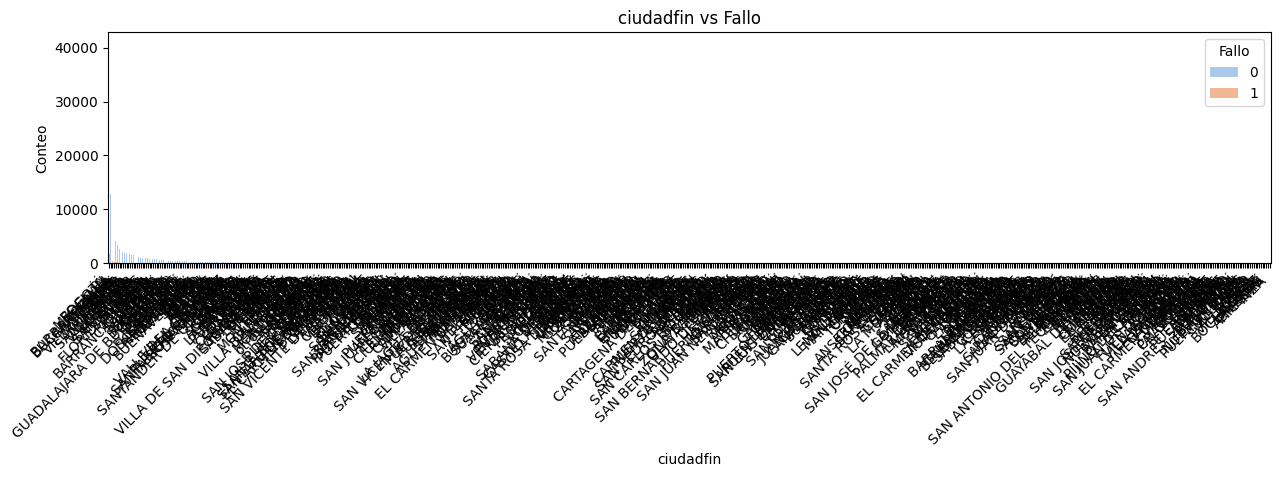

In [ ]:
# Seleccionar solo las variables categóricas
categorical_vars = desarrollo.select_dtypes(include=['object', 'category']).columns

# Definir una paleta de colores (opcional)
custom_palette = sns.color_palette("pastel")

for var in categorical_vars:
    # Contar las ocurrencias de cada categoría y ordenar por frecuencia
    value_counts = desarrollo[var].value_counts()
    ordered_categories = value_counts.index

    # Gráfico de distribución de la variable
    plt.figure(figsize=(min(15, len(value_counts) * 1.5), 3))
    sns.countplot(x=desarrollo[var], order=ordered_categories)
    plt.title(f'Distribución de {var} por Fallo')
    plt.xlabel(var)
    plt.ylabel('Conteo')
    plt.xticks(rotation=45, ha='right')
    plt.show()

    # Gráfico de comparación con la variable fallo
    plt.figure(figsize=(min(15, len(value_counts) * 1.5), 3))
    sns.countplot(x=desarrollo[var], hue=desarrollo['fallo'], order=ordered_categories, palette=custom_palette)
    plt.title(f'{var} vs Fallo')
    plt.xlabel(var)
    plt.ylabel('Conteo')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Fallo')
    plt.show()

#### 3.9 Análisis chi-cuadrado cualitativo vs target

In [ ]:
# DataFrame original
df = desarrollo.fillna(desarrollo.mode().iloc[0])

# Seleccionar todas las variables cualitativas (de tipo 'object' o 'category')
df_cualitativas = df.select_dtypes(include=['object', 'category'])

# Definir la variable objetivo
target_variable = "fallo"

# Realizar pruebas de chi-cuadrado para cada variable cualitativa vs la variable "evento"
resultados_chi_cuadrado = {}

for columna in df_cualitativas.columns:
    if columna != target_variable:
        tabla_contingencia = pd.crosstab(df_cualitativas[columna], df[target_variable])
        chi2, p, _, _ = chi2_contingency(tabla_contingencia)
        resultados_chi_cuadrado[columna] = p

# Ordenar los resultados por el valor de p (menor a mayor)
resultados_ordenados = sorted(resultados_chi_cuadrado.items(), key=lambda x: x[1])

# Mostrar los resultados ordenados
print("Variables más significativas:")
for variable, p_valor in resultados_ordenados:
    print(f"{variable}: p-valor = {p_valor}")


/tmp/ipykernel_34/2005236695.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = desarrollo.fillna(desarrollo.mode().iloc[0])


Variables más significativas:
tecnologiapp: p-valor = 0.0
modelopp: p-valor = 0.0
tecnologiaaf: p-valor = 0.0
modeloaf: p-valor = 0.0
mcc: p-valor = 5.695253733829841e-178
browser: p-valor = 2.3298038764168105e-103
grupo_version_ant: p-valor = 2.1256300362666215e-94
grupo_version: p-valor = 1.7224995852907156e-56
ciudadfin: p-valor = 1.110109709834232e-19


#### 3.10 Análisis de frecuencía por variable target

In [ ]:
#Frecuencia por variable.
for variable in variables_cualitativas:
  tabla_frecuencia = df.groupby([variable, 'fallo'])['fallo'].size().unstack(fill_value=0).reset_index()
  tabla_frecuencia.columns = ['fallo', 'No Fallo', 'Fallo']  # Renombrar columnas (opcional)
  print(f"Tabla de frecuencia para {variable}:\n{tabla_frecuencia}\n")

Tabla de frecuencia para fallo:
   fallo  No Fallo  Fallo
0      0    134491      0
1      1         0   5507

Tabla de frecuencia para tecnologiapp:
  fallo  No Fallo  Fallo
0     a    102962   2862
1     b     31426   2645
2    cd       103      0

Tabla de frecuencia para modelopp:
       fallo  No Fallo  Fallo
0          a      5279    321
1          c     16105    342
2          d      4695    372
3          i      5928     88
4          j     79965   2413
5          k      2805    263
6          l     11876   1101
7          m       832     40
8          n      5226    494
9   qofpegbh       849     54
10         r       931     19

Tabla de frecuencia para tecnologiaaf:
  fallo  No Fallo  Fallo
0     a     18114    507
1     b     80408   2236
2     c     30968   2622
3    de      5001    142

Tabla de frecuencia para modeloaf:
   fallo  No Fallo  Fallo
0      a      4289    281
1      b     15947    342
2      c      4640    374
3      g      4871    136
4      h     23267    5

#### 3.11 Dumización de Variables cualitativas.

In [ ]:
# Obtener las variables tipo objeto, excluyendo "fallo"
variables_objeto = desarrollo.select_dtypes(include=['object']).columns.drop('fallo')

# Aplicar codificación one-hot a las variables tipo objeto, excluyendo "fallo"
desarrollo = pd.get_dummies(desarrollo, columns=variables_objeto, drop_first=True)

In [ ]:
desarrollo

,fallo,total_terminales,cantidad_falla_m3,cantidad_falla_m2,cantidad_falla_mes1,antiguedad_creacion_terminal,antiguedad_version,antiguedad_compra_pos,antiguedad_puesta_pos,trx_mes_mediana,...,ciudadfin_YOTOCO,ciudadfin_YUMBO,ciudadfin_ZAMBRANO,ciudadfin_ZAPATOCA,ciudadfin_ZARZAL,ciudadfin_ZIPACÓN,ciudadfin_ZIPAQUIRÁ,ciudadfin_ZONA BANANERA,ciudadfin_otros_ciudadfin,ciudadfin_ÚTICA
id,,,,,,,,,,,,,,,,,,,,,
Cy1AyK,0,3,0,0,0,1770,707,2502,278,168.0,...,False,False,False,False,False,False,False,False,False,False
UfC1Td,0,3,0,0,0,769,530,1542,273,201.0,...,False,False,False,False,False,False,False,False,False,False
ECDP8i,0,3,0,0,0,188,187,1911,187,528.0,...,False,False,False,False,False,False,False,False,False,False
vI3rKZ,0,3,0,0,0,304,301,375,273,21.0,...,False,False,False,False,False,False,False,False,False,False
3hG7Yd,0,3,0,0,0,2229,551,655,278,114.0,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DepVv9,0,3,0,0,0,3388,640,2624,12,102.0,...,False,False,False,False,False,False,False,False,False,False
Wdaipi,0,3,0,0,0,691,160,1546,107,102.0,...,False,False,False,False,False,False,False,False,False,False
MIyuIO,0,3,0,0,0,1074,912,2139,271,579.0,...,False,False,False,False,False,False,False,False,False,False


#### 4.0 Preparación de las tablas de entrenamiento y prueba

In [ ]:
# Eliminar la columna 'evento' y 'ID' de la lista de columnas seleccionadas
columnas_seleccionadas = [col for col in desarrollo if col not in ['fallo']]

# Seleccionar las columnas finales para X
X = desarrollo[columnas_seleccionadas]

# Seleccionar la variable objetivo
y = desarrollo['fallo']

#### 4.1 Seleccion de variables

#### 4.2 Remuestreo

In [ ]:
# Asegurarse de que la variable 'evento' sea binaria (0 y 1)
# Si está codificada como texto, la convertimos a binaria
if y.dtype == 'object':
    label_encoder = LabelEncoder()
    y = label_encoder.fit_transform(y)

# Dividir el conjunto de datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.6, random_state=1234)

# Aplicar SMOTE para balancear el conjunto de entrenamiento
smote = SMOTE(random_state=1234)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Aplicar LassoCV para seleccionar características importantes
lasso = LassoCV(cv=5, random_state=1234)
lasso.fit(X_train_resampled, y_train_resampled)


# Seleccionar las características no eliminadas por Lasso (coeficientes distintos de 0)
#selected_features = X_train.columns[(lasso.coef_ != 0).tolist()]

# Redefinir X_train y X_test usando solo las características seleccionadas
#X_train = X_train_resampled[selected_features]
#X_test = X_test[selected_features]


LassoCV(cv=5, random_state=1234)

#### 4.3 Modelos

#### 4.3.1 Regresion Logistica

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pandas as pd
import numpy as np

# Crear el modelo de regresión logística
logreg = LogisticRegression(solver='liblinear')  # Solver adecuado para problemas de regularización L1

# Obtener las características seleccionadas por LassoCV
selected_features = X_train.columns[lasso.coef_ != 0]

# Entrenar el modelo con las características seleccionadas
logreg.fit(X_train_resampled[selected_features], y_train_resampled)

# Realizar predicciones en el conjunto de prueba y en el conjunto de entrenamiento
y_pred_train = logreg.predict(X_train_resampled[selected_features])
y_pred_test = logreg.predict(X_test[selected_features])

# Evaluar el modelo en el conjunto de entrenamiento
accuracy_train = accuracy_score(y_train_resampled, y_pred_train)
conf_matrix_train = confusion_matrix(y_train_resampled, y_pred_train)
class_report_train = classification_report(y_train_resampled, y_pred_train)

# Evaluar el modelo en el conjunto de prueba
accuracy_test = accuracy_score(y_test, y_pred_test)
conf_matrix_test = confusion_matrix(y_test, y_pred_test)
class_report_test = classification_report(y_test, y_pred_test)

# Mostrar resultados de la muestra de entrenamiento
print("Resultados del conjunto de entrenamiento:")
print(f"Precisión del modelo: {accuracy_train}")
print("Matriz de Confusión:")
print(conf_matrix_train)
print("\nReporte de Clasificación:")
print(class_report_train)

# Mostrar resultados de la muestra de prueba
print("\nResultados del conjunto de prueba:")
print(f"Precisión del modelo: {accuracy_test}")
print("Matriz de Confusión:")
print(conf_matrix_test)
print("\nReporte de Clasificación:")
print(class_report_test)

# Análisis de coeficientes (importancia de las variables)
coef = logreg.coef_[0]  # Los coeficientes de la regresión logística
odds_ratios = np.exp(coef)  # Calcular los Odds Ratios (OR)

# Crear un DataFrame para mostrar la relevancia de las variables
coef_df = pd.DataFrame({
    'Feature': selected_features,
    'Coefficient': coef,
    'Odds Ratio': odds_ratios
})

# Ordenar el DataFrame por la magnitud del OR en orden descendente
coef_df = coef_df.sort_values(by='Odds Ratio', ascending=False)

print("\nAnálisis de Coeficientes y Odds Ratios:")
print(coef_df)

# Interpretación de los coeficientes
print("\nInterpretación:")
for index, row in coef_df.iterrows():
    if row['Odds Ratio'] > 1:
        print(f"La variable '{row['Feature']}' incrementa la probabilidad del evento.")
    elif row['Odds Ratio'] < 1:
        print(f"La variable '{row['Feature']}' disminuye la probabilidad del evento.")
    else:
        print(f"La variable '{row['Feature']}' no tiene un efecto significativo en la probabilidad del evento.")


Resultados del conjunto de entrenamiento:
Precisión del modelo: 0.9151609785114135
Matriz de Confusión:
[[45208  8588]
 [  540 53256]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.99      0.84      0.91     53796
           1       0.86      0.99      0.92     53796

    accuracy                           0.92    107592
   macro avg       0.92      0.92      0.91    107592
weighted avg       0.92      0.92      0.91    107592


Resultados del conjunto de prueba:
Precisión del modelo: 0.8454386361742402
Matriz de Confusión:
[[67748 12947]
 [   36  3268]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       1.00      0.84      0.91     80695
           1       0.20      0.99      0.33      3304

    accuracy                           0.85     83999
   macro avg       0.60      0.91      0.62     83999
weighted avg       0.97      0.85      0.89     83999


Análisis de Coeficientes y 

Matriz de Confusión para el conjunto de entrenamiento:
[[45208  8588]
 [  540 53256]]

Matriz de Confusión para el conjunto de prueba:
[[67748 12947]
 [   36  3268]]

F1-score para el conjunto de entrenamiento: 0.9210653753026633
F1-score para el conjunto de prueba: 0.33485321993954614

Precisión para el conjunto de entrenamiento: 0.9151609785114135
Precisión para el conjunto de prueba: 0.8454386361742402


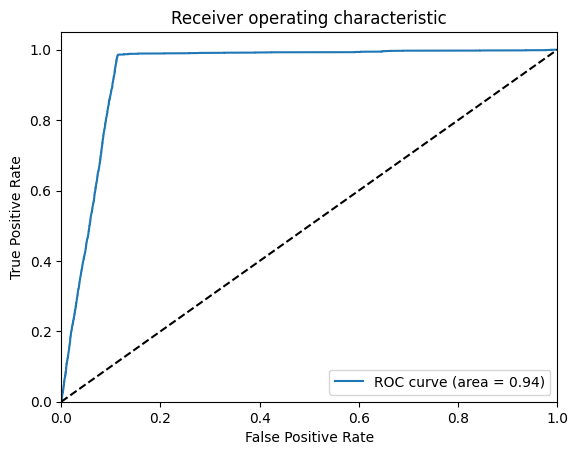

Umbral óptimo: 0.8325199216804858
Matriz de confusión con umbral óptimo:
[[71476  9219]
 [   47  3257]]


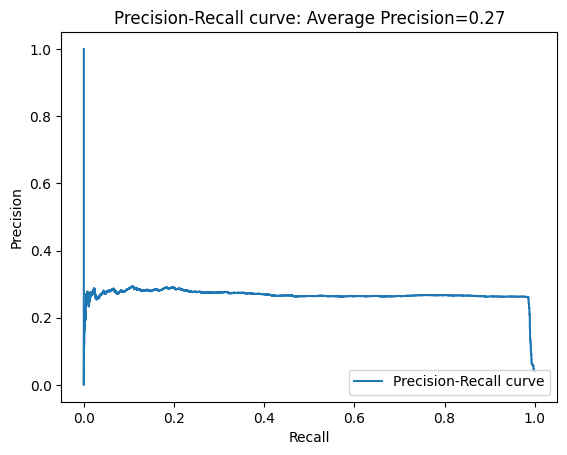

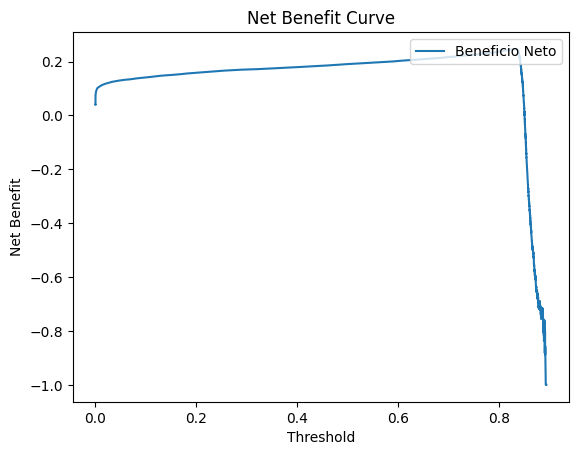

In [ ]:
# Suponiendo que ya tienes tus datos divididos en X_train, X_test, y_train, y_test
# y que has aplicado SMOTE y LassoCV

# Entrenar el modelo con las características seleccionadas
logreg.fit(X_train_resampled[selected_features], y_train_resampled)

# Realizar predicciones en el conjunto de entrenamiento y prueba
y_pred_train = logreg.predict(X_train_resampled[selected_features])
y_pred_test = logreg.predict(X_test[selected_features])

# Calcular la matriz de confusión para el conjunto de entrenamiento y prueba
conf_matrix_train = confusion_matrix(y_train_resampled, y_pred_train)
conf_matrix_test = confusion_matrix(y_test, y_pred_test)

print("Matriz de Confusión para el conjunto de entrenamiento:")
print(conf_matrix_train)
print("\nMatriz de Confusión para el conjunto de prueba:")
print(conf_matrix_test)

# Calcular el puntaje F1 para el conjunto de entrenamiento y prueba
f1_train = f1_score(y_train_resampled, y_pred_train)
f1_test = f1_score(y_test, y_pred_test)

print("\nF1-score para el conjunto de entrenamiento:", f1_train)
print("F1-score para el conjunto de prueba:", f1_test)

# Calcular la precisión para el conjunto de entrenamiento y prueba
accuracy_train = accuracy_score(y_train_resampled, y_pred_train)
accuracy_test = accuracy_score(y_test, y_pred_test)

print("\nPrecisión para el conjunto de entrenamiento:", accuracy_train)
print("Precisión para el conjunto de prueba:", accuracy_test)


# Calcular las probabilidades predichas
y_pred_proba = logreg.predict_proba(X_test[selected_features])[:, 1]

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.show()

# Encontrar el umbral óptimo
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print(f'Umbral óptimo: {optimal_threshold}')

# Usar el umbral óptimo para predecir
y_pred_optimal = (y_pred_proba >= optimal_threshold).astype(int)
conf_matrix_optimal = confusion_matrix(y_test, y_pred_optimal)
print('Matriz de confusión con umbral óptimo:')
print(conf_matrix_optimal)

# Curva de precisión-recall
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)
average_precision = average_precision_score(y_test, y_pred_proba)

plt.plot(recall, precision, label='Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall curve: Average Precision={0:0.2f}'.format(
    average_precision))
plt.legend(loc="lower right")
plt.show()
# Beneficio neto
benefit = (precision * recall) - ((1 - precision) * (1 - recall))
plt.plot(thresholds, benefit[:-1], label='Beneficio Neto')
plt.xlabel('Threshold')
plt.ylabel('Net Benefit')
plt.title('Net Benefit Curve')
plt.legend(loc="upper right")
plt.show()

#### 4.3.2 Árbol de decisión

Matriz de Confusión para el conjunto de entrenamiento:
[[53785    11]
 [   14 53782]]

Matriz de Confusión para el conjunto de prueba:
[[77414  3281]
 [ 1547  1757]]

F1-score para el conjunto de entrenamiento: 0.9997676342377009
F1-score para el conjunto de prueba: 0.42124190841524817

Precisión para el conjunto de entrenamiento: 0.9997676407167819
Precisión para el conjunto de prueba: 0.9425231252753009


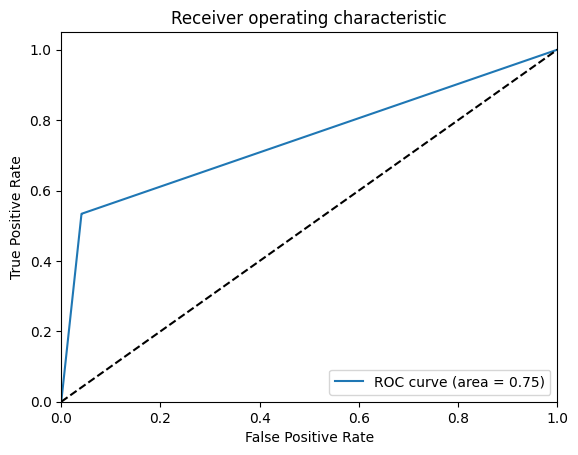

Umbral óptimo: 0.5
Matriz de confusión con umbral óptimo:
[[77399  3296]
 [ 1540  1764]]


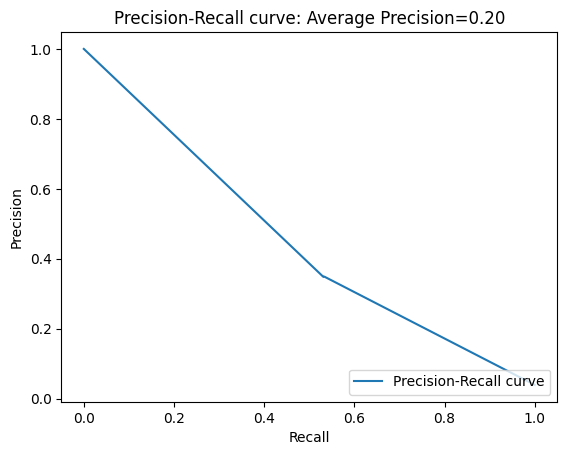

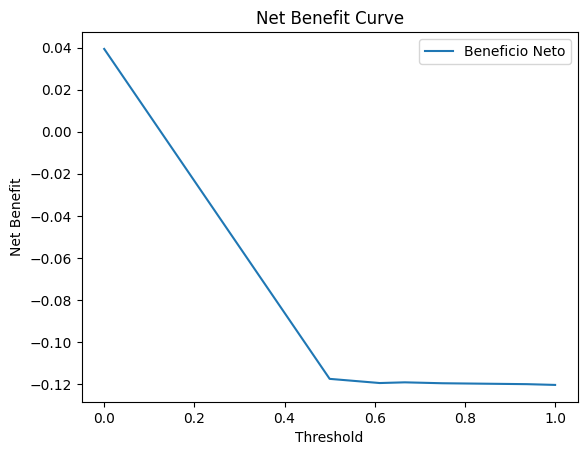

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, roc_curve, auc, precision_recall_curve, average_precision_score

# Suponiendo que ya tienes tus datos divididos en X_train, X_test, y_train, y_test
# y que has aplicado SMOTE y LassoCV

# Crear el modelo de árbol de decisión
tree = DecisionTreeClassifier()

# Entrenar el modelo con las características seleccionadas
tree.fit(X_train_resampled[selected_features], y_train_resampled)

# Realizar predicciones en el conjunto de entrenamiento y prueba
y_pred_train = tree.predict(X_train_resampled[selected_features])
y_pred_test = tree.predict(X_test[selected_features])

# Calcular la matriz de confusión para el conjunto de entrenamiento y prueba
conf_matrix_train = confusion_matrix(y_train_resampled, y_pred_train)
conf_matrix_test = confusion_matrix(y_test, y_pred_test)

print("Matriz de Confusión para el conjunto de entrenamiento:")
print(conf_matrix_train)
print("\nMatriz de Confusión para el conjunto de prueba:")
print(conf_matrix_test)

# Calcular el puntaje F1 para el conjunto de entrenamiento y prueba
f1_train = f1_score(y_train_resampled, y_pred_train)
f1_test = f1_score(y_test, y_pred_test)

print("\nF1-score para el conjunto de entrenamiento:", f1_train)
print("F1-score para el conjunto de prueba:", f1_test)

# Calcular la precisión para el conjunto de entrenamiento y prueba
accuracy_train = accuracy_score(y_train_resampled, y_pred_train)
accuracy_test = accuracy_score(y_test, y_pred_test)

print("\nPrecisión para el conjunto de entrenamiento:", accuracy_train)
print("Precisión para el conjunto de prueba:", accuracy_test)

# Calcular las probabilidades predichas
y_pred_proba = tree.predict_proba(X_test[selected_features])[:, 1]

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.show()

# Encontrar el umbral óptimo
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print(f'Umbral óptimo: {optimal_threshold}')

# Usar el umbral óptimo para predecir
y_pred_optimal = (y_pred_proba >= optimal_threshold).astype(int)
conf_matrix_optimal = confusion_matrix(y_test, y_pred_optimal)
print('Matriz de confusión con umbral óptimo:')
print(conf_matrix_optimal)

# Curva de precisión-recall
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)
average_precision = average_precision_score(y_test, y_pred_proba)

plt.plot(recall, precision, label='Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall curve: Average Precision={0:0.2f}'.format(
    average_precision))
plt.legend(loc="lower right")
plt.show()

# Beneficio neto
benefit = (precision * recall) - ((1 - precision) * (1 - recall))
plt.plot(thresholds, benefit[:-1], label='Beneficio Neto')
plt.xlabel('Threshold')
plt.ylabel('Net Benefit')
plt.title('Net Benefit Curve')
plt.legend(loc="upper right")
plt.show()


#### 4.3.3 Red Neuronal Poco profunda

2024-08-19 13:47:33.777410: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-08-19 13:47:33.777550: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-08-19 13:47:33.906859: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
/opt/conda/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
 105/3363 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.6067 - loss: 20.4314   

I0000 00:00:1724075270.256224     250 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


3363/3363 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8254 - loss: 2.9496
Epoch 2/15
3363/3363 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8686 - loss: 0.8554
Epoch 3/15
3363/3363 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8884 - loss: 0.4857
Epoch 4/15
3363/3363 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.9062 - loss: 0.3500
Epoch 5/15
3363/3363 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.9166 - loss: 0.2846
Epoch 6/15
3363/3363 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.9261 - loss: 0.2508
Epoch 7/15
3363/3363 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.9315 - loss: 0.2317
Epoch 8/15
3363/3363 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.9327 - loss: 0.2249
Epoch 9/15
3363/3363 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.9342 - loss: 0.2215
Epoch 10/15
3363/3363 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.9363 - loss: 0.2150
Epoch 11/15
3363/3363 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.9348 - loss: 0.2161
Epoch 12/15
3363/3363 ━━━━━━━━━━━━━━━━━━━

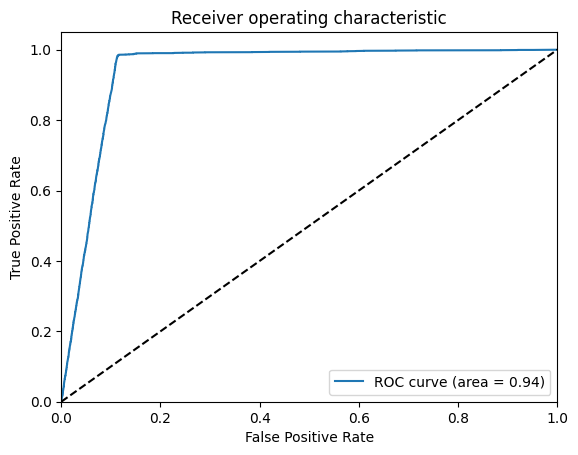

Umbral óptimo: 0.35406339168548584
Matriz de confusión con umbral óptimo:
[[71342  9353]
 [   47  3257]]


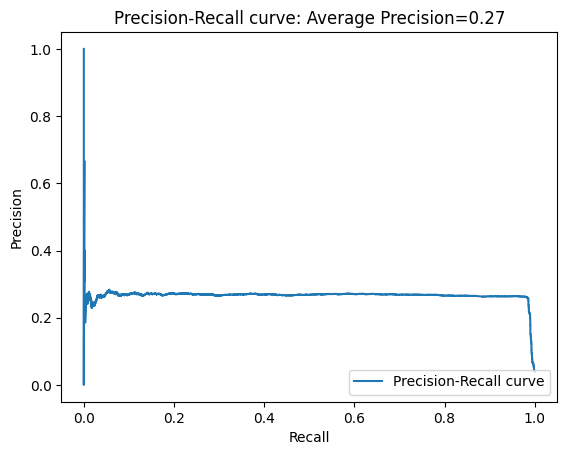

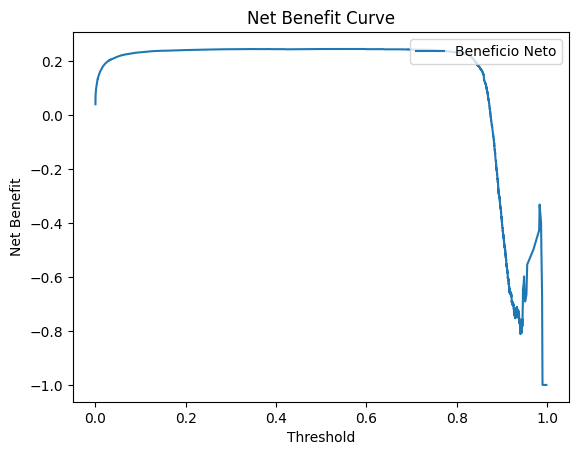

In [ ]:
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, roc_curve, auc, precision_recall_curve, average_precision_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt
import numpy as np

# Suponiendo que ya tienes tus datos divididos en X_train, X_test, y_train, y_test
# y que has aplicado SMOTE y LassoCV

# Crear el modelo de red neuronal poco profunda
model = Sequential()
model.add(Dense(64, input_dim=len(selected_features), activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# Compilar el modelo
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Entrenar el modelo con las características seleccionadas
model.fit(X_train_resampled[selected_features], y_train_resampled, epochs=15, batch_size=32, verbose=1) #26 epocas

# Realizar predicciones en el conjunto de entrenamiento y prueba
y_pred_train = (model.predict(X_train_resampled[selected_features]) >= 0.5).astype(int)
y_pred_test = (model.predict(X_test[selected_features]) >= 0.5).astype(int)

# Calcular la matriz de confusión para el conjunto de entrenamiento y prueba
conf_matrix_train = confusion_matrix(y_train_resampled, y_pred_train)
conf_matrix_test = confusion_matrix(y_test, y_pred_test)

print("Matriz de Confusión para el conjunto de entrenamiento:")
print(conf_matrix_train)
print("\nMatriz de Confusión para el conjunto de prueba:")
print(conf_matrix_test)

# Calcular el puntaje F1 para el conjunto de entrenamiento y prueba
f1_train = f1_score(y_train_resampled, y_pred_train)
f1_test = f1_score(y_test, y_pred_test)

print("\nF1-score para el conjunto de entrenamiento:", f1_train)
print("F1-score para el conjunto de prueba:", f1_test)

# Calcular la precisión para el conjunto de entrenamiento y prueba
accuracy_train = accuracy_score(y_train_resampled, y_pred_train)
accuracy_test = accuracy_score(y_test, y_pred_test)

print("\nPrecisión para el conjunto de entrenamiento:", accuracy_train)
print("Precisión para el conjunto de prueba:", accuracy_test)

# Calcular las probabilidades predichas
y_pred_proba = model.predict(X_test[selected_features])

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.show()

# Encontrar el umbral óptimo
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print(f'Umbral óptimo: {optimal_threshold}')

# Usar el umbral óptimo para predecir
y_pred_optimal = (y_pred_proba >= optimal_threshold).astype(int)
conf_matrix_optimal = confusion_matrix(y_test, y_pred_optimal)
print('Matriz de confusión con umbral óptimo:')
print(conf_matrix_optimal)

# Curva de precisión-recall
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)
average_precision = average_precision_score(y_test, y_pred_proba)

plt.plot(recall, precision, label='Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall curve: Average Precision={0:0.2f}'.format(
    average_precision))
plt.legend(loc="lower right")
plt.show()

# Beneficio neto
benefit = (precision * recall) - ((1 - precision) * (1 - recall))
plt.plot(thresholds, benefit[:-1], label='Beneficio Neto')
plt.xlabel('Threshold')
plt.ylabel('Net Benefit')
plt.title('Net Benefit Curve')
plt.legend(loc="upper right")
plt.show()


Nota:

La siguiente es una red neuronal profunda con varias capas ocultas y capas de dropout para prevenir el sobreajuste. El modelo tiene tres capas ocultas con 128, 64 y 32 neuronas respectivamente, y una capa de salida con una neurona y activación sigmoide para la clasificación binaria

#### 4.3.4 Red neuronal profunda

Epoch 1/10


/opt/conda/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3363/3363 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - accuracy: 0.5473 - loss: 10.0533
Epoch 2/10
3363/3363 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.7914 - loss: 0.4774
Epoch 3/10
3363/3363 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8894 - loss: 0.3292
Epoch 4/10
3363/3363 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9053 - loss: 0.2989
Epoch 5/10
3363/3363 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9151 - loss: 0.2721
Epoch 6/10
3363/3363 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9187 - loss: 0.2646
Epoch 7/10
3363/3363 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9231 - loss: 0.2525
Epoch 8/10
3363/3363 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9236 - loss: 0.2493
Epoch 9/10
3363/3363 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9267 - loss: 0.2397
Epoch 10/10
3363/3363 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.9263 - loss: 0.2404
3363/3363 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step
2625/2625 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
Matriz de Confusión para el conjunto de en

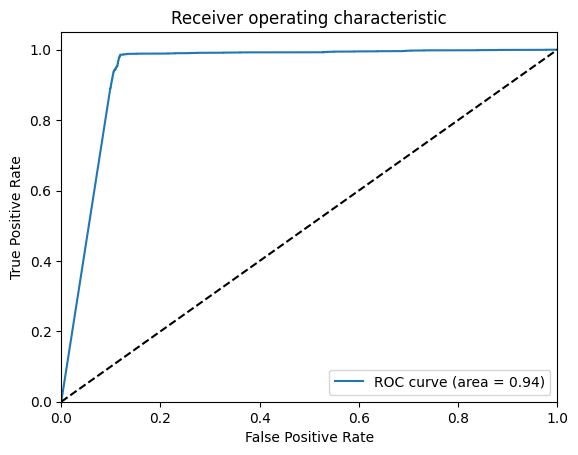

Umbral óptimo: 0.5212348699569702
Matriz de confusión con umbral óptimo:
[[71080  9615]
 [   46  3258]]


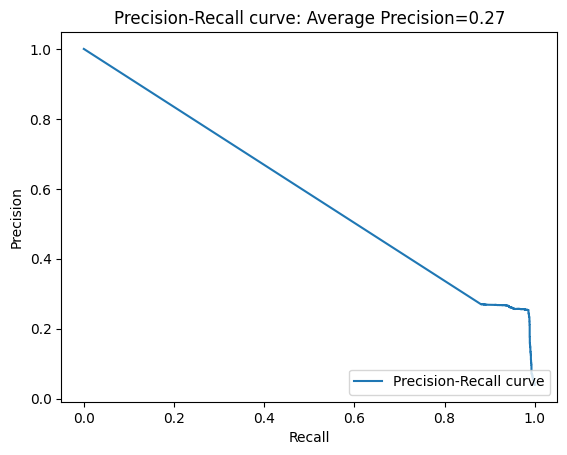

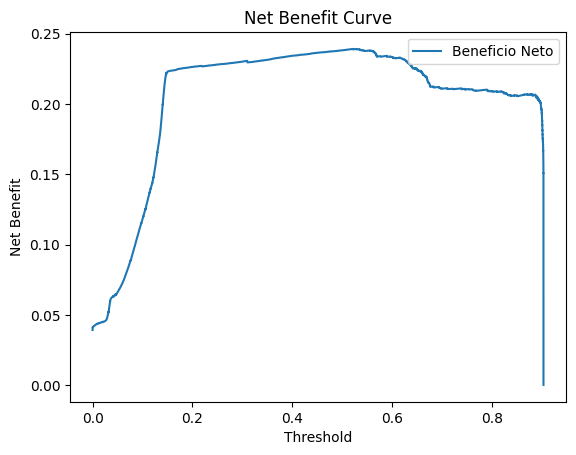

In [ ]:
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, roc_curve, auc, precision_recall_curve, average_precision_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Crear el modelo de red neuronal profunda
model = Sequential()
model.add(Dense(128, input_dim=len(selected_features), activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# Compilar el modelo
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Entrenar el modelo con las características seleccionadas
model.fit(X_train_resampled[selected_features], y_train_resampled, epochs=10, batch_size=32, verbose=1)

# Realizar predicciones en el conjunto de entrenamiento y prueba
y_pred_train = (model.predict(X_train_resampled[selected_features]) >= 0.5).astype(int)
y_pred_test = (model.predict(X_test[selected_features]) >= 0.5).astype(int)

# Calcular la matriz de confusión para el conjunto de entrenamiento y prueba
conf_matrix_train = confusion_matrix(y_train_resampled, y_pred_train)
conf_matrix_test = confusion_matrix(y_test, y_pred_test)

print("Matriz de Confusión para el conjunto de entrenamiento:")
print(conf_matrix_train)
print("\nMatriz de Confusión para el conjunto de prueba:")
print(conf_matrix_test)

# Calcular el puntaje F1 para el conjunto de entrenamiento y prueba
f1_train = f1_score(y_train_resampled, y_pred_train)
f1_test = f1_score(y_test, y_pred_test)

print("\nF1-score para el conjunto de entrenamiento:", f1_train)
print("F1-score para el conjunto de prueba:", f1_test)

# Calcular la precisión para el conjunto de entrenamiento y prueba
accuracy_train = accuracy_score(y_train_resampled, y_pred_train)
accuracy_test = accuracy_score(y_test, y_pred_test)

print("\nPrecisión para el conjunto de entrenamiento:", accuracy_train)
print("Precisión para el conjunto de prueba:", accuracy_test)

# Calcular las probabilidades predichas
y_pred_proba = model.predict(X_test[selected_features])

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.show()

# Encontrar el umbral óptimo
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print(f'Umbral óptimo: {optimal_threshold}')

# Usar el umbral óptimo para predecir
y_pred_optimal = (y_pred_proba >= optimal_threshold).astype(int)
conf_matrix_optimal = confusion_matrix(y_test, y_pred_optimal)
print('Matriz de confusión con umbral óptimo:')
print(conf_matrix_optimal)

# Curva de precisión-recall
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)
average_precision = average_precision_score(y_test, y_pred_proba)

plt.plot(recall, precision, label='Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall curve: Average Precision={0:0.2f}'.format(
    average_precision))
plt.legend(loc="lower right")
plt.show()

# Beneficio neto
benefit = (precision * recall) - ((1 - precision) * (1 - recall))
plt.plot(thresholds, benefit[:-1], label='Beneficio Neto')
plt.xlabel('Threshold')
plt.ylabel('Net Benefit')
plt.title('Net Benefit Curve')
plt.legend(loc="upper right")
plt.show()


SVM

In [ ]:
"""
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, roc_curve, auc, precision_recall_curve, average_precision_score


# Crear el modelo de SVM
svm = SVC(probability=True)

# Entrenar el modelo con las características seleccionadas
svm.fit(X_train_resampled[selected_features], y_train_resampled)

# Realizar predicciones en el conjunto de entrenamiento y prueba
y_pred_train = svm.predict(X_train_resampled[selected_features])
y_pred_test = svm.predict(X_test[selected_features])

# Calcular la matriz de confusión para el conjunto de entrenamiento y prueba
conf_matrix_train = confusion_matrix(y_train_resampled, y_pred_train)
conf_matrix_test = confusion_matrix(y_test, y_pred_test)

print("Matriz de Confusión para el conjunto de entrenamiento:")
print(conf_matrix_train)
print("\nMatriz de Confusión para el conjunto de prueba:")
print(conf_matrix_test)

# Calcular el puntaje F1 para el conjunto de entrenamiento y prueba
f1_train = f1_score(y_train_resampled, y_pred_train)
f1_test = f1_score(y_test, y_pred_test)

print("\nF1-score para el conjunto de entrenamiento:", f1_train)
print("F1-score para el conjunto de prueba:", f1_test)

# Calcular la precisión para el conjunto de entrenamiento y prueba
accuracy_train = accuracy_score(y_train_resampled, y_pred_train)
accuracy_test = accuracy_score(y_test, y_pred_test)

print("\nPrecisión para el conjunto de entrenamiento:", accuracy_train)
print("Precisión para el conjunto de prueba:", accuracy_test)

# Calcular las probabilidades predichas
y_pred_proba = svm.predict_proba(X_test[selected_features])[:, 1]

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.show()

# Encontrar el umbral óptimo
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print(f'Umbral óptimo: {optimal_threshold}')

# Usar el umbral óptimo para predecir
y_pred_optimal = (y_pred_proba >= optimal_threshold).astype(int)
conf_matrix_optimal = confusion_matrix(y_test, y_pred_optimal)
print('Matriz de confusión con umbral óptimo:')
print(conf_matrix_optimal)

# Curva de precisión-recall
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)
average_precision = average_precision_score(y_test, y_pred_proba)

plt.plot(recall, precision, label='Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall curve: Average Precision={0:0.2f}'.format(
    average_precision))
plt.legend(loc="lower right")
plt.show()

# Beneficio neto
benefit = (precision * recall) - ((1 - precision) * (1 - recall))
plt.plot(thresholds, benefit[:-1], label='Beneficio Neto')
plt.xlabel('Threshold')
plt.ylabel('Net Benefit')
plt.title('Net Benefit Curve')
plt.legend(loc="upper right")
plt.show()
"""

#### 4.3.5 Random Forest

Matriz de Confusión para el conjunto de entrenamiento:
[[53775    21]
 [    4 53792]]

Matriz de Confusión para el conjunto de prueba:
[[76239  4456]
 [  976  2328]]

F1-score para el conjunto de entrenamiento: 0.9997676774247507
F1-score para el conjunto de prueba: 0.46153846153846156

Precisión para el conjunto de entrenamiento: 0.9997676407167819
Precisión para el conjunto de prueba: 0.9353325634828986


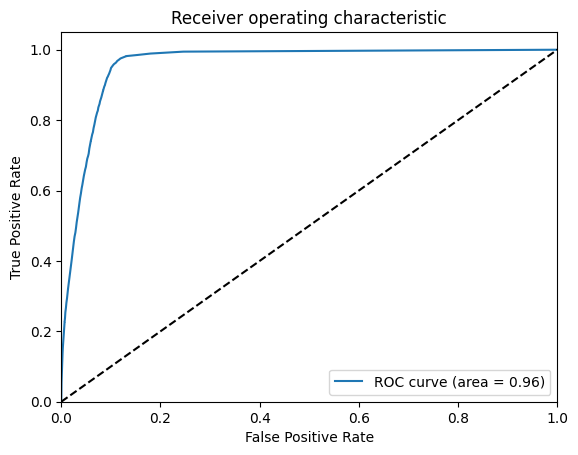

Umbral óptimo: 0.06842105263157895
Matriz de confusión con umbral óptimo:
[[71067  9628]
 [   82  3222]]


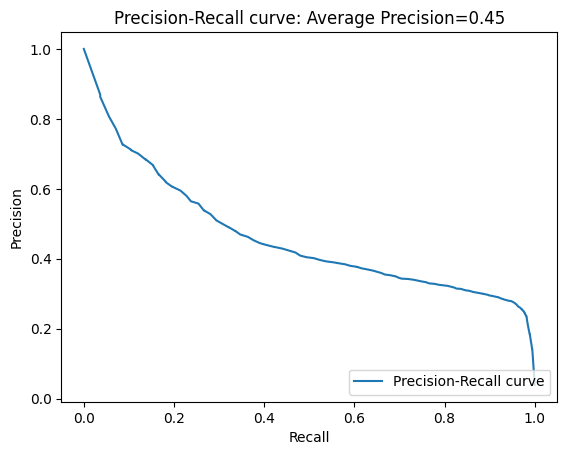

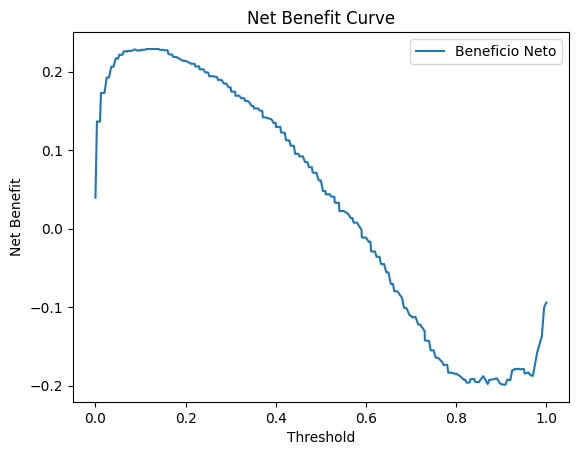

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import numpy as np

# Suponiendo que ya tienes tus datos divididos en X_train, X_test, y_train, y_test
# y que has aplicado SMOTE y LassoCV

# Crear el modelo de Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Entrenar el modelo con las características seleccionadas
rf.fit(X_train_resampled[selected_features], y_train_resampled)

# Realizar predicciones en el conjunto de entrenamiento y prueba
y_pred_train = rf.predict(X_train_resampled[selected_features])
y_pred_test = rf.predict(X_test[selected_features])

# Calcular la matriz de confusión para el conjunto de entrenamiento y prueba
conf_matrix_train = confusion_matrix(y_train_resampled, y_pred_train)
conf_matrix_test = confusion_matrix(y_test, y_pred_test)

print("Matriz de Confusión para el conjunto de entrenamiento:")
print(conf_matrix_train)
print("\nMatriz de Confusión para el conjunto de prueba:")
print(conf_matrix_test)

# Calcular el puntaje F1 para el conjunto de entrenamiento y prueba
f1_train = f1_score(y_train_resampled, y_pred_train)
f1_test = f1_score(y_test, y_pred_test)

print("\nF1-score para el conjunto de entrenamiento:", f1_train)
print("F1-score para el conjunto de prueba:", f1_test)

# Calcular la precisión para el conjunto de entrenamiento y prueba
accuracy_train = accuracy_score(y_train_resampled, y_pred_train)
accuracy_test = accuracy_score(y_test, y_pred_test)

print("\nPrecisión para el conjunto de entrenamiento:", accuracy_train)
print("Precisión para el conjunto de prueba:", accuracy_test)

# Calcular las probabilidades predichas
y_pred_proba = rf.predict_proba(X_test[selected_features])[:, 1]

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.show()

# Encontrar el umbral óptimo
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print(f'Umbral óptimo: {optimal_threshold}')

# Usar el umbral óptimo para predecir
y_pred_optimal = (y_pred_proba >= optimal_threshold).astype(int)
conf_matrix_optimal = confusion_matrix(y_test, y_pred_optimal)
print('Matriz de confusión con umbral óptimo:')
print(conf_matrix_optimal)

# Curva de precisión-recall
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)
average_precision = average_precision_score(y_test, y_pred_proba)

plt.plot(recall, precision, label='Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall curve: Average Precision={0:0.2f}'.format(
    average_precision))
plt.legend(loc="lower right")
plt.show()

# Beneficio neto
benefit = (precision * recall) - ((1 - precision) * (1 - recall))
plt.plot(thresholds, benefit[:-1], label='Beneficio Neto')
plt.xlabel('Threshold')
plt.ylabel('Net Benefit')
plt.title('Net Benefit Curve')
plt.legend(loc="upper right")
plt.show()

#### 5.0 Selección y guardado del mejor modelo

In [ ]:
import joblib
# Guardar el modelo entrenado como un archivo .pkl
filename = 'modelo_random_forest.pkl'
joblib.dump(rf, filename)

print(f"Modelo guardado como {filename}")

Modelo guardado como modelo_random_forest.pkl


In [ ]:
"""
import pickle

# Supongamos que ya has encontrado el mejor modelo
mejor_modelo = modelos[mejor_modelo_idx]

# Guardar el mejor modelo en un archivo .pkl
with open('mejor_modelo.pkl', 'wb') as file:
    pickle.dump(mejor_modelo, file)

print("El mejor modelo ha sido guardado como 'mejor_modelo.pkl'")

"""

'\nimport pickle\n\n# Supongamos que ya has encontrado el mejor modelo\nmejor_modelo = modelos[mejor_modelo_idx]\n\n# Guardar el mejor modelo en un archivo .pkl\nwith open(\'mejor_modelo.pkl\', \'wb\') as file:\n    pickle.dump(mejor_modelo, file)\n\nprint("El mejor modelo ha sido guardado como \'mejor_modelo.pkl\'")\n\n'

#### 6.0 Puesta en producción

In [ ]:
# Cargar el archivo .parquet
produccion = pd.read_parquet('/kaggle/input/produccion')

In [ ]:
produccion.head(3)

,tecnologiapp,modelopp,tecnologiaaf,modeloaf,browser,grupo_version,mcc,grupo_version_ant,ciudadfin,trx_dia_cero,...,prom_mes_dos,prom_mes_uno,total_terminales,cantidad_falla_m3,cantidad_falla_m2,cantidad_falla_mes1,antiguedad_creacion_terminal,antiguedad_version,antiguedad_compra_pos,antiguedad_puesta_pos
id,,,,,,,,,,,,,,,,,,,,,
OTSPeD,a,j,b,i,j,h,aax,h,TULUÁ,12,...,11.766667,10.3,60,0,3,66,1919,657,2309,273
L6Tkh1,a,i,b,i,j,h,az,b,CÚCUTA,3,...,2.400000,3.8,3,3,0,0,1780,772,2497,159
kAWzV7,a,j,a,h,g,e,at,e,BOGOTÁ,0,...,0.400000,0.2,3,0,0,0,2804,1343,2112,278


In [ ]:
# 1. Identificar las columnas que comienzan con 'trx_dia_', 'trx_mes_' y 'prom_mes_'
trx_dia_cols = [col for col in produccion.columns if col.startswith('trx_dia_')]
trx_mes_cols = [col for col in produccion.columns if col.startswith('trx_mes_')]
prom_mes_cols = [col for col in produccion.columns if col.startswith('prom_mes_')]

# 2. Calcular las medianas y crear las nuevas columnas
produccion['trx_dia_mediana'] = produccion[trx_dia_cols].median(axis=1)
produccion['trx_mes_mediana'] = produccion[trx_mes_cols].median(axis=1)
produccion['prom_mes_mediana'] = produccion[prom_mes_cols].median(axis=1)

# 3. Eliminar las columnas originales utilizadas para calcular las medianas
produccion.drop(columns=trx_dia_cols + trx_mes_cols + prom_mes_cols, inplace=True)

In [ ]:
# 4. Elimino variable multicolinealidad
produccion.drop(columns=["prom_mes_mediana", "trx_dia_mediana"], inplace=True)

In [ ]:
# 5. Atipicos Uso de las funciones con el dataset 'produccion'
produccion = detectar_y_reemplazar_atipicos(produccion)

In [ ]:
# 6. Estandarización de las variables

# Seleccionar solo las variables numéricas para estandarizar, excluyendo la variable 'fallo'
numericas = produccion.select_dtypes(include=['int64', 'float64'])

# Inicializar el objeto StandardScaler
scaler = StandardScaler()

# Ajustar y transformar los datos numéricos
numericas_estandarizadas = scaler.fit_transform(numericas)

# Crear un nuevo DataFrame con las variables estandarizadas, conservando los índices originales
numericas_estandarizadas_df = pd.DataFrame(numericas_estandarizadas, columns=numericas.columns, index=produccion.index)

# Combinar las variables estandarizadas con las variables categóricas
train_t = pd.concat([numericas_estandarizadas_df, produccion.select_dtypes(include=['object'])], axis=1)

# Reconstruir el DataFrame final incluyendo la variable objetivo 'fallo'
#produccion = pd.concat([produccion[['fallo']], train_t], axis=1)

# Verificar si hay valores nulos
print(produccion.isnull().sum())


tecnologiapp                    0
modelopp                        0
tecnologiaaf                    0
modeloaf                        0
browser                         0
grupo_version                   0
mcc                             0
grupo_version_ant               0
ciudadfin                       0
total_terminales                0
cantidad_falla_m3               0
cantidad_falla_m2               0
cantidad_falla_mes1             0
antiguedad_creacion_terminal    0
antiguedad_version              0
antiguedad_compra_pos           0
antiguedad_puesta_pos           0
trx_mes_mediana                 0
dtype: int64


In [ ]:
# 7. Agrupacion de variables
# Agrupación de categorías en la variable "tecnologiapp"
produccion['tecnologiapp'] = produccion['tecnologiapp'].replace({'c': 'cd', 'd': 'cd'})

# Agrupación de categorías en la variable "modelopp"
produccion['modelopp'] = produccion['modelopp'].replace({'q': 'qofpegbh', 'o': 'qofpegbh', 'f': 'qofpegbh', 'p': 'qofpegbh',
                                                         'e': 'qofpegbh', 'g': 'qofpegbh', 'b': 'qofpegbh', 'h': 'qofpegbh'})

# Agrupación de categorías en la variable "tecnologiaaf"
produccion['tecnologiaaf'] = produccion['tecnologiaaf'].replace({'d': 'de', 'e': 'de'})

# Agrupación de categorías en la variable "modeloaf"
produccion['modeloaf'] = produccion['modeloaf'].replace({'m': 'mledf', 'l': 'mledf', 'e': 'mledf', 'd': 'mledf', 'f': 'mledf'})

# Agrupación de categorías en la variable "browser"
produccion['browser'] = produccion['browser'].replace({'b': 'bkamld', 'k': 'bkamld', 'a': 'bkamld', 'm': 'bkamld',
                                                       'l': 'bkamld', 'd': 'bkamld'})

# Agrupación de categorías en la variable "grupo_version"
produccion['grupo_version'] = produccion['grupo_version'].replace({'a': 'aic', 'i': 'aic', 'c': 'aic'})

# Agrupación de categorías en la variable "grupo_version_ant"
produccion['grupo_version_ant'] = produccion['grupo_version_ant'].replace({'i': 'ija', 'j': 'ija', 'a': 'ija'})

# Agrupación de categorías únicas en "mcc"
categorias_grupo_mcc = produccion['mcc'].value_counts()
categorias_unicas_grupo_mcc = categorias_grupo_mcc[categorias_grupo_mcc == 1].index
produccion['mcc'] = produccion['mcc'].replace(categorias_unicas_grupo_mcc, 'otros_grupo_mcc')

# Agrupación de categorías únicas en "ciudadfin"
categorias_ciudadfin = produccion['ciudadfin'].value_counts()
categorias_unicas_ciudadfin = categorias_ciudadfin[categorias_ciudadfin == 1].index
produccion['ciudadfin'] = produccion['ciudadfin'].replace(categorias_unicas_ciudadfin, 'otros_ciudadfin')


#### 7.0 Implementacion del modelo

In [ ]:
# Guardar el modelo entrenado como un archivo .pkl
filename = 'modelo_random_forest.pkl'
joblib.dump(rf, filename)

print(f"Modelo guardado como {filename}")

Modelo guardado como modelo_random_forest.pkl


In [ ]:
# Cargar el modelo guardado
filename = 'modelo_random_forest.pkl'
rf_loaded = joblib.load(filename)

# Suponiendo que el DataFrame 'produccion' contiene las mismas características que se usaron en el entrenamiento
# Filtrar las columnas necesarias según 'selected_features'
X_produccion = produccion[selected_features]

# Realizar predicciones con el modelo cargado
produccion['prediccion_fallo'] = rf_loaded.predict(X_produccion)

# Si también necesitas obtener las probabilidades para la clase positiva (fallo = 1)
produccion['probabilidad_fallo'] = rf_loaded.predict_proba(X_produccion)[:, 1]

# Mostrar las primeras filas del DataFrame con las predicciones
print(produccion.head())

       tecnologiapp modelopp tecnologiaaf modeloaf browser grupo_version  mcc  \
id                                                                              
OTSPeD            a        j            b        i       j             h  aax   
L6Tkh1            a        i            b        i       j             h   az   
kAWzV7            a        j            a        h       g             e   at   
Hf9ley            a        j            b        i       j             h   aj   
4rmmQi            a        j            b        i       h             g  aax   

       grupo_version_ant     ciudadfin  total_terminales  cantidad_falla_m3  \
id                                                                            
OTSPeD                 h         TULUÁ                 3                  0   
L6Tkh1                 b        CÚCUTA                 3                  0   
kAWzV7                 e        BOGOTÁ                 3                  0   
Hf9ley                 k        CÚCUT

In [ ]:
produccion

,tecnologiapp,modelopp,tecnologiaaf,modeloaf,browser,grupo_version,mcc,grupo_version_ant,ciudadfin,total_terminales,cantidad_falla_m3,cantidad_falla_m2,cantidad_falla_mes1,antiguedad_creacion_terminal,antiguedad_version,antiguedad_compra_pos,antiguedad_puesta_pos,trx_mes_mediana,prediccion_fallo,probabilidad_fallo
id,,,,,,,,,,,,,,,,,,,,
OTSPeD,a,j,b,i,j,h,aax,h,TULUÁ,3,0,0,0,1919,657,2309,273,102.0,0,0.00
L6Tkh1,a,i,b,i,j,h,az,b,CÚCUTA,3,0,0,0,1780,772,2497,159,216.0,0,0.01
kAWzV7,a,j,a,h,g,e,at,e,BOGOTÁ,3,0,0,0,2804,1343,2112,278,36.0,0,0.00
Hf9ley,a,j,b,i,j,h,aj,k,CÚCUTA,3,0,0,0,1022,42,2387,42,21.0,0,0.00
4rmmQi,a,j,b,i,h,g,aax,e,DOSQUEBRADAS,3,0,0,0,1425,139,2385,139,417.0,0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
HyqpaZ,b,n,c,k,h,g,aan,e,BOGOTÁ,3,0,0,0,1717,439,2332,0,108.0,1,0.65
vdCdSl,a,c,a,b,g,e,aar,k,SOGAMOSO,3,0,0,0,1678,595,1911,279,15.0,0,0.00
jtxrfZ,a,j,b,h,g,g,aaaaae,e,TUMACO,3,0,0,0,3636,937,2240,278,147.0,0,0.00


#### 7.1 Se realiza una clasificación usando percentiles

In [ ]:
# Definir las condiciones basadas en los percentiles y los valores de probabilidad
def clasificar_riesgo(probabilidad):
    if probabilidad >= produccion['probabilidad_fallo'].quantile(0.99):
        return "1.Muy críticos"
    elif probabilidad >= produccion['probabilidad_fallo'].quantile(0.95):
        return "2.Críticos"
    elif probabilidad >= produccion['probabilidad_fallo'].quantile(0.88):
        return "3.Muy sensibles"
    elif probabilidad >= produccion['probabilidad_fallo'].quantile(0.80):
        return "4.Sensibles"
    else:
        return "5.Moderado"

# Aplicar la clasificación al DataFrame
produccion['rangos_de_riesgo'] = produccion['probabilidad_fallo'].apply(clasificar_riesgo)


# Verificar los primeros registros para confirmar la categorización
print(produccion[['probabilidad_fallo', 'rangos_de_riesgo']].head())


        probabilidad_fallo rangos_de_riesgo
id                                         
OTSPeD                0.00       5.Moderado
L6Tkh1                0.01       5.Moderado
kAWzV7                0.00       5.Moderado
Hf9ley                0.00       5.Moderado
4rmmQi                0.00       5.Moderado


#### 7.2 exportacion de resultados .parquet

In [ ]:
# Exportar el DataFrame a un archivo Parquet
produccion.to_parquet('produccion_salida.parquet')

#### 8.0 fin